# Models

## Data analysis

### Robot_related

Statements:
- 1 - "Os robôs são benéficos para a sociedade, porque ajudam as pessoas." - positivo
- 2 - "Atribuir tarefas de rotina aos robôs permite que as pessoas se dediquem a tarefas mais significativas." - positivo
- 3 - "Receio que os robôs incentivem uma menor interação entre os seres humanos." - negatvio 
- 4 - "As tarefas perigosas devem ser atribuídas, em primeiro lugar, aos robôs." - positivo
- 5 - "A utilização generalizada de robôs vai tirar empregos às pessoas." - negativo 
- 6 - "A utilização não regulamentada da robótica pode levar a mudanças sociais." - negativo 

Statements 3, 5, and 6 are negative, and 1, 2, and 4 are positive. If we reverse the negative statements, we end up with a spectrum ranging from anti-robot to pro-robot, where 1 represents the most anti-robot opinion and 6 represents the most pro-robot opinion.

In the next cell, we take the data obtained from the study and create a JSON file containing only studies with the topic “robot_related,” with the negative questions already inverted.

In [51]:
import json
import pandas as pd
import numpy as np

questionnaire_to_discussion = {
    "socio-economic": {1:"q_socio-economic_1",2:"q_socio-economic_2",3:"q_socio-economic_3",4:"q_socio-economic_4",5:"q_socio-economic_5",6:"q_socio-economic_6"},
    "robot_related":  {1:"q_robot_related_5", 2:"q_robot_related_3", 3:"q_robot_related_8", 4:"q_robot_related_4", 5:"q_robot_related_7", 6:"q_robot_related_10"},
}

knowledge_questionnaire_to_discussion = {
    "socio-economic": {1:"q_knowledge_socio-economic_1",2:"q_knowledge_socio-economic_2",3:"q_knowledge_socio-economic_3",4:"q_knowledge_socio-economic_4",5:"q_knowledge_socio-economic_5",6:"q_knowledge_socio-economic_6"},
    "robot_related":  {1:"q_knowledge_robot_related_5", 2:"q_knowledge_robot_related_3", 3:"q_knowledge_robot_related_8", 4:"q_knowledge_robot_related_4", 5:"q_knowledge_robot_related_7", 6:"q_knowledge_robot_related_10"},
}

    
with open("./responses_9_6.json") as f:
    data = json.load(f)


data = {k: v for k, v in data.items() if k != "1"}

rows = []
for pid, p in data.items():
    statements = {}
    if(p["topic"] == "robot_related"):
        for rn, rv in p["rounds"].items():
            stmt_id = int(rv["statement_id"])
            
            key = questionnaire_to_discussion[p["topic"]][stmt_id]
            key_knowledge = knowledge_questionnaire_to_discussion[p["topic"]][stmt_id]+"_1"
            key_interest = knowledge_questionnaire_to_discussion[p["topic"]][stmt_id]+"_2"

            statements["order_"+str(stmt_id)]            = int(rn) + 1
            statements["agents_"+str(stmt_id)]           = rv["agents"]
            statements["condition_"+str(stmt_id)]        = rv["condition"]
            statements["knowledge_"+str(stmt_id)]        = p["pre"].get(key_knowledge)
            statements["interest_"+str(stmt_id)]         = p["pre"].get(key_interest)
            
            if(stmt_id == 3 or stmt_id == 5 or stmt_id == 6):
                statements["pre_"+str(stmt_id)]              = 7-int(p["pre"].get(key))
                statements["public_"+str(stmt_id)]           = 7-int(rv.get("participant_public_opinion"))
                statements["priv_"+str(stmt_id)]             = 7-int(p["pro"].get(key))
                statements["delta_pre_public_"+str(stmt_id)] = -1*(int(rv.get("participant_public_opinion"))-int(p["pre"].get(key)))
                statements["delta_pre_priv_"+str(stmt_id)]   = -1*(int(p["pro"].get(key)) - int(p["pre"].get(key)))
            else:
                statements["pre_"+str(stmt_id)]              = p["pre"].get(key)
                statements["public_"+str(stmt_id)]           = rv.get("participant_public_opinion")
                statements["priv_"+str(stmt_id)]             = p["pro"].get(key)
                statements["delta_pre_public_"+str(stmt_id)] = int(rv.get("participant_public_opinion"))-int(p["pre"].get(key))
                statements["delta_pre_priv_"+str(stmt_id)]   = int(p["pro"].get(key)) - int(p["pre"].get(key))
            
        statements = dict(sorted(statements.items()))
        
        rows.append({
                    "participant_id":       pid,
                    "topic":                p["topic"],
                    "field_sutdy":          p["pre"]["course"],
                    "age":                  p["pre"]["age"],
                    "ai_freq":              p["pro"]["ai_freq"],
                    "robot_freq":           p["pro"]["robot_freq"],
                    **statements
                })

with open("./data_final_pro_anti_robots.json", "w", encoding="utf-8") as f:
    json.dump(rows, f, ensure_ascii=False, indent=2)

#### Participants Anti Robot vs Pro Robot

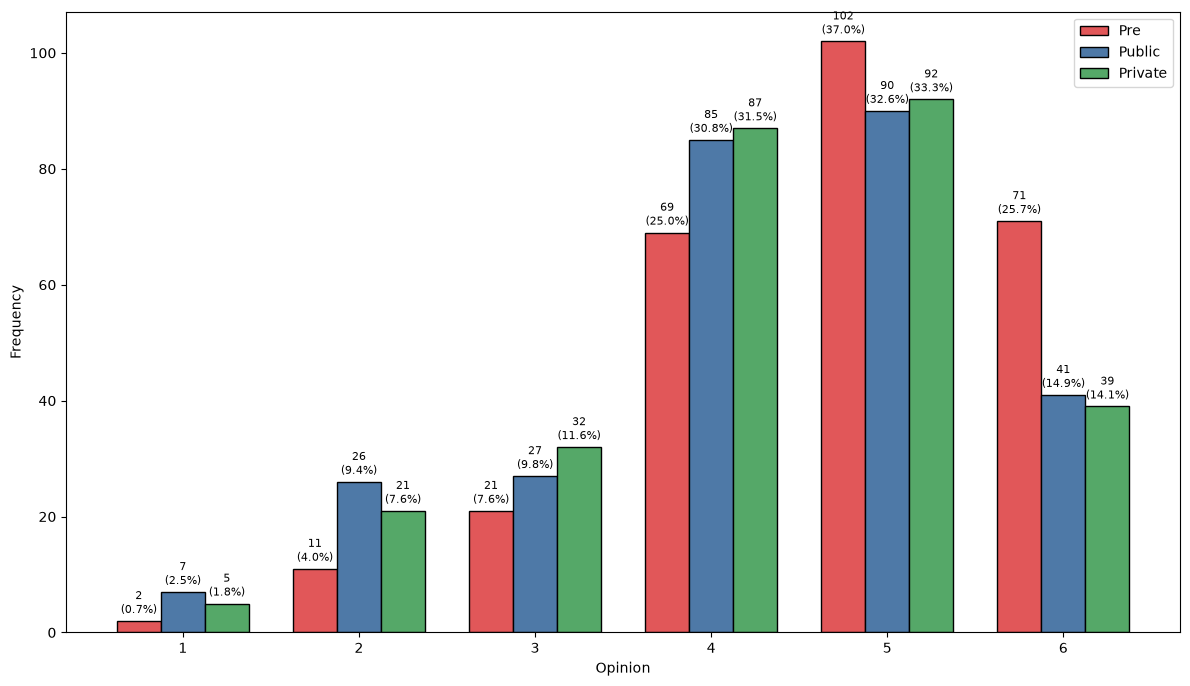

In [19]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
stmt_ids = [1, 2, 3, 4, 5, 6]

pre = []
public = []
priv = []
for row in data:
    for sid in stmt_ids:
        if(row["topic"] == "robot_related"):
            pre.append(int(row["pre_" + str(sid)]))
            public.append(int(row["public_" + str(sid)]))
            priv.append(int(row["priv_" + str(sid)]))

# valores possíveis
valores = [1, 2, 3, 4, 5, 6]

# contar frequências de cada valor em cada lista
pre_counts = [pre.count(v) for v in valores]
public_counts = [public.count(v) for v in valores]
priv_counts = [priv.count(v) for v in valores]

# totais para calcular percentagens
total_pre = len(pre)
total_public = len(public)
total_priv = len(priv)

# posições das barras
x = np.arange(len(valores))
largura = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

barras_pre = ax.bar(x - largura, pre_counts, width=largura, edgecolor="black", label="Pre", color="#E15759")
barras_public = ax.bar(x, public_counts, width=largura, edgecolor="black", label="Public", color="#4E79A7")
barras_priv = ax.bar(x + largura, priv_counts, width=largura, edgecolor="black", label="Private", color="#55A868")



ax.set_xlabel("Opinion")
ax.set_ylabel("Frequency")
ax.set_xticks(x)
ax.set_xticklabels(valores)
ax.legend()

# função para adicionar rótulos com número e percentagem
def adicionar_rotulos(barras, counts, total):
    for barra, count in zip(barras, counts):
        altura = barra.get_height()
        pct = 100 * count / total if total > 0 else 0
        ax.annotate(
            f"{count}\n({pct:.1f}%)",
            xy=(barra.get_x() + barra.get_width() / 2, altura),
            xytext=(0, 3),  # deslocamento vertical em pontos
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=8
        )

adicionar_rotulos(barras_pre, pre_counts, total_pre)
adicionar_rotulos(barras_public, public_counts, total_public)
adicionar_rotulos(barras_priv, priv_counts, total_priv)

plt.tight_layout()
plt.show()

#### Which participants were the least likely to change their opinions?

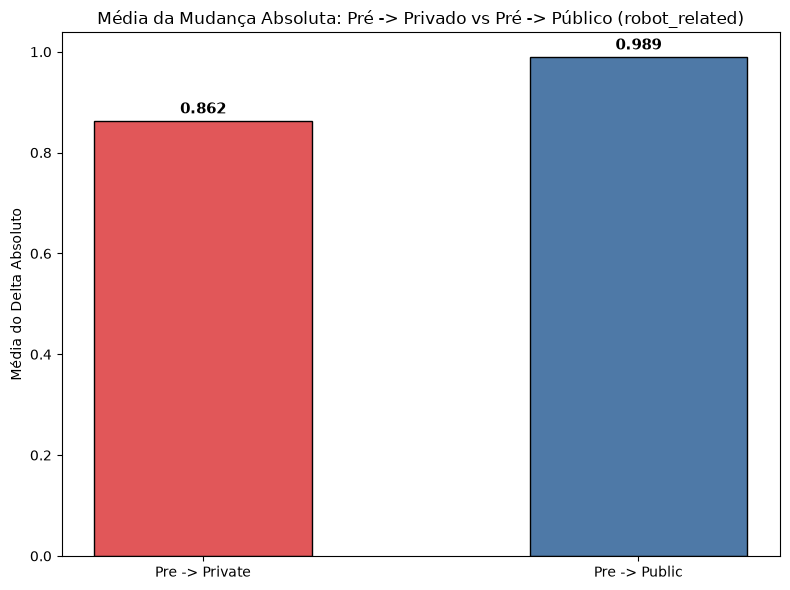

In [20]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
stmt_ids = [1, 2, 3, 4, 5, 6]

participants_delta_public_pre = []
participants_delta_priv_pre = []
for row in data:
    for sid in stmt_ids:
        if row["topic"] == "robot_related":
            participants_delta_priv_pre.append(int(row["delta_pre_priv_" + str(sid)]))
            participants_delta_public_pre.append(int(row["delta_pre_public_" + str(sid)]))

means = {
    "Pre -> Private": np.mean(np.abs(participants_delta_priv_pre)),
    "Pre -> Public": np.mean(np.abs(participants_delta_public_pre))
}

labels = list(means.keys())
valores = list(means.values())

fig, ax = plt.subplots(figsize=(8, 6))

barras = ax.bar(labels, valores, color=["#E15759", "#4E79A7"], edgecolor="black", width=0.5)



ax.set_ylabel("Média do Delta Absoluto")
ax.set_title("Média da Mudança Absoluta: Pré -> Privado vs Pré -> Público (robot_related)")

# adicionar rótulo com o valor por cima de cada barra
for barra, valor in zip(barras, valores):
    altura = barra.get_height()
    ax.annotate(
        f"{valor:.3f}",
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )

plt.tight_layout()
plt.show()

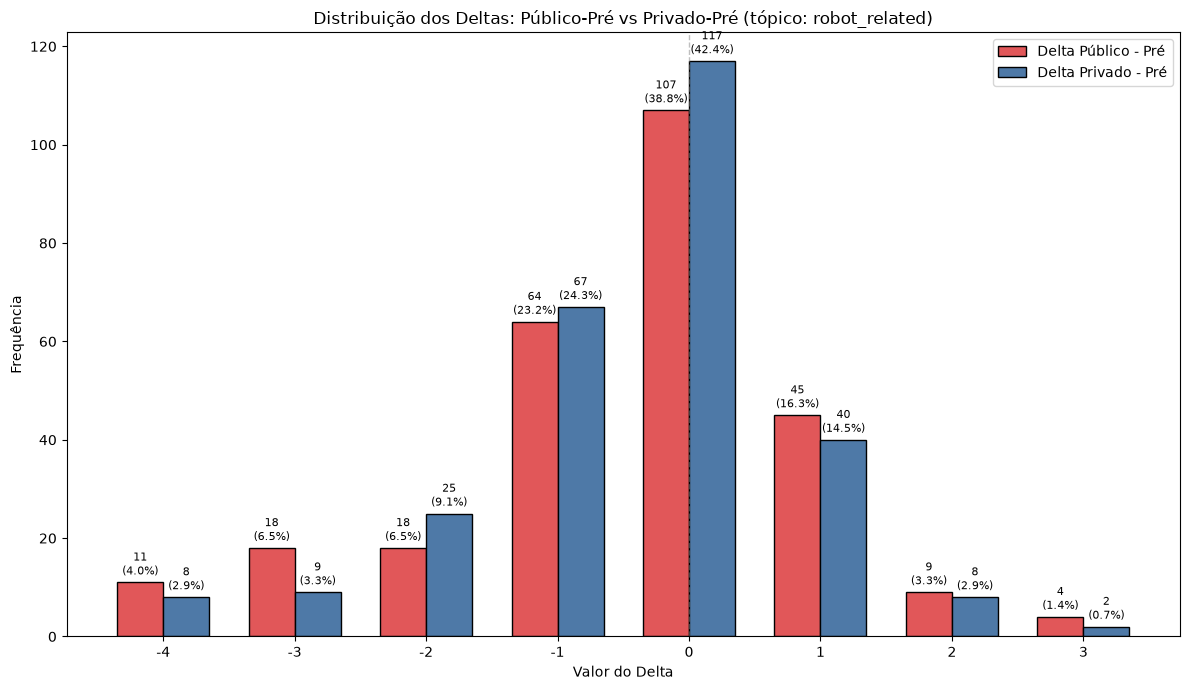

In [21]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
stmt_ids = [1, 2, 3, 4, 5, 6]

participants_delta_public_pre = []
participants_delta_priv_pre = []
for row in data:
    for sid in stmt_ids:
        if row["topic"] == "robot_related":
            participants_delta_priv_pre.append(int(row["delta_pre_priv_" + str(sid)]))
            participants_delta_public_pre.append(int(row["delta_pre_public_" + str(sid)]))

# determinar todos os valores possíveis presentes nos dados (deltas podem ser negativos)
todos_valores = sorted(set(participants_delta_public_pre) | set(participants_delta_priv_pre))

# contar frequências de cada valor em cada lista
public_counts = [participants_delta_public_pre.count(v) for v in todos_valores]
priv_counts = [participants_delta_priv_pre.count(v) for v in todos_valores]

# totais para calcular percentagens
total_public = len(participants_delta_public_pre)
total_priv = len(participants_delta_priv_pre)

# posições das barras
x = np.arange(len(todos_valores))
largura = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

barras_public = ax.bar(x - largura/2, public_counts, edgecolor="black", width=largura, label="Delta Público - Pré", color="#E15759")
barras_priv = ax.bar(x + largura/2, priv_counts, edgecolor="black", width=largura, label="Delta Privado - Pré", color="#4E79A7")



ax.set_xlabel("Valor do Delta")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição dos Deltas: Público-Pré vs Privado-Pré (tópico: robot_related)")
ax.set_xticks(x)
ax.set_xticklabels(todos_valores)
ax.axvline(x=np.where(np.array(todos_valores) == 0)[0][0] if 0 in todos_valores else None,
           color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.legend()

# função para adicionar rótulos com número e percentagem
def adicionar_rotulos(barras, counts, total):
    for barra, count in zip(barras, counts):
        altura = barra.get_height()
        pct = 100 * count / total if total > 0 else 0
        ax.annotate(
            f"{count}\n({pct:.1f}%)",
            xy=(barra.get_x() + barra.get_width() / 2, altura),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=8
        )

adicionar_rotulos(barras_public, public_counts, total_public)
adicionar_rotulos(barras_priv, priv_counts, total_priv)

plt.tight_layout()
plt.savefig("histograma_deltas.png", dpi=150)
plt.show()

#### Delta - Robots vs Virtuals vs News Articles - Overall Activites

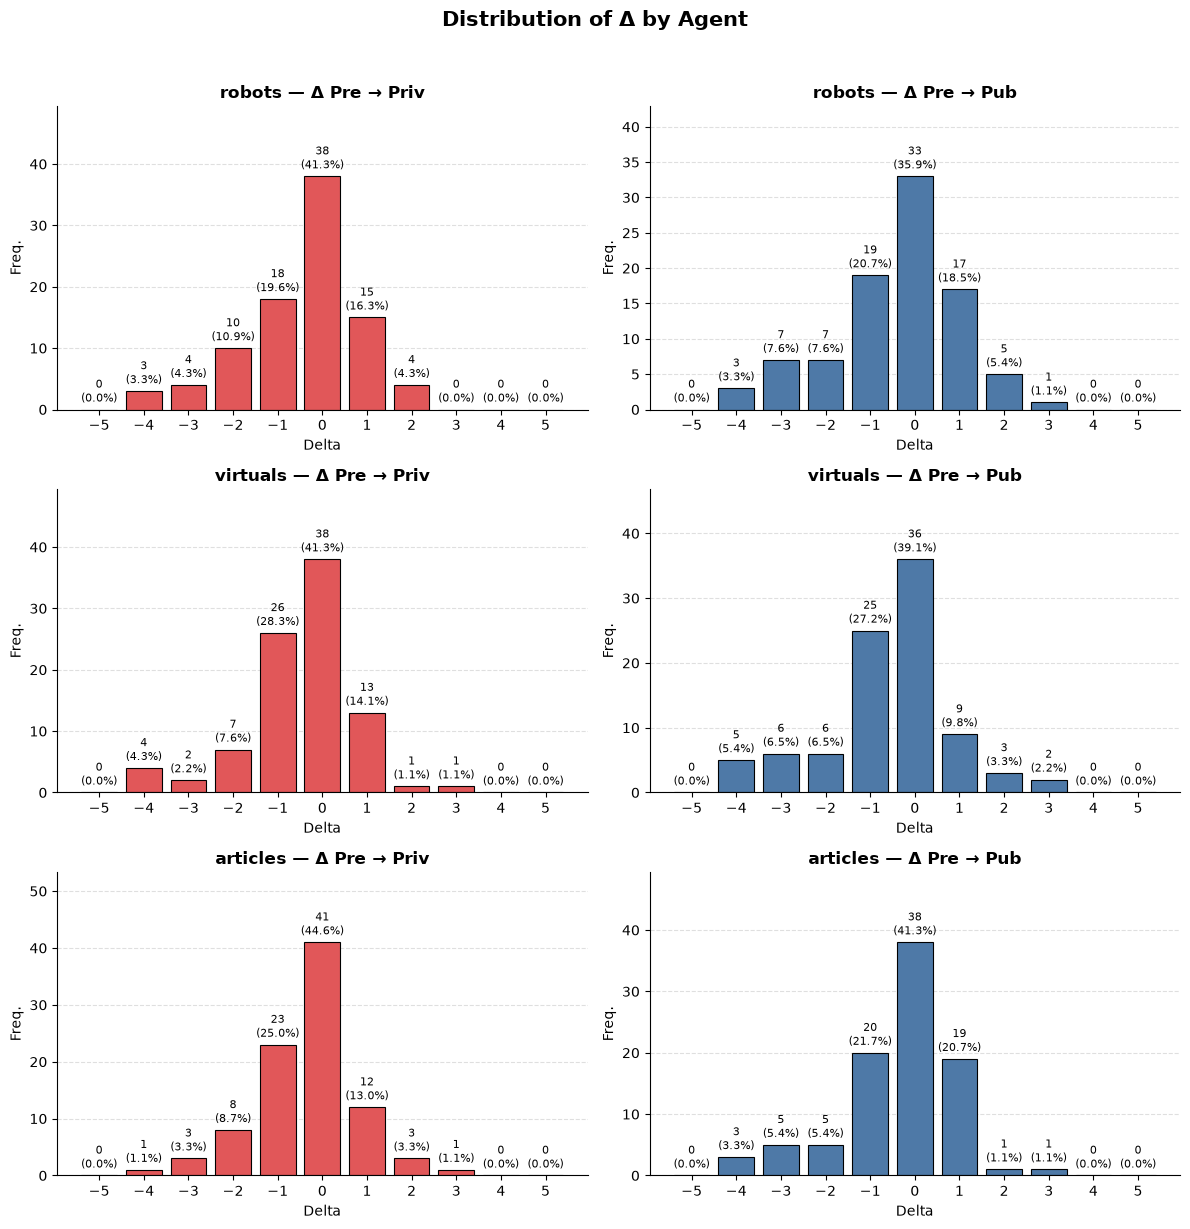

In [28]:
import json
import pandas as pd
import numpy as np

with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
stmt_ids = [1, 2, 3, 4, 5, 6]

pre_public = []
pre_priv = []

    

for ag in agents:
    pre_priv_aux = []
    pre_public_aux = []
    for row in data:
        for sid in stmt_ids:
            if(row["agents_"+str(sid)] == ag and row["topic"] == "robot_related"):
                pre_priv_aux.append(int(row["delta_pre_priv_"+str(sid)]))
                pre_public_aux.append(int(row["delta_pre_public_"+str(sid)]))

    pre_public.append(pre_public_aux)
    pre_priv.append(pre_priv_aux)

lo, hi = -5, 5
bins = range(lo, hi + 2)

fig, axes = plt.subplots(len(agents), 2, figsize=(12, 4 * len(agents)))

cor_public = "#4E79A7"
cor_priv = "#E15759"


for i, ag in enumerate(agents):
    pre_public_ag = pre_public[i]
    pre_priv_ag = pre_priv[i]


    for j, (nome, valores, cor) in enumerate([
        
        ("Pre → Priv", pre_priv_ag, cor_priv),
        ("Pre → Pub", pre_public_ag, cor_public),
    ]):
        ax = axes[i, j]
        counts, edges, patches = ax.hist(
            valores, bins=bins, align="left", rwidth=0.8,
            color=cor, edgecolor="black", linewidth=0.8
        )
        total = len(valores)
        labels = [f"{int(c)}\n({c/total*100:.1f}%)" if total > 0 else "0" for c in counts]
        ax.bar_label(patches, labels=labels, padding=3, fontsize=8)

        ax.set_title(f"{ag} — Δ {nome}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Delta")
        ax.set_ylabel("Freq.")
        ax.set_xticks(range(lo, hi + 1))
        ax.set_ylim(0, max(counts) * 1.3 if len(counts) else 1)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.set_axisbelow(True)

fig.suptitle("Distribution of Δ by Agent", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

As can be seen, participants were less likely to change their opinions after reading articles and more likely to do so after interacting with robots, although the difference is not significant.

### Socio-economic

In this model, we will use a left-right scale. In this case, the left-right positions will be determined based on the parties for which the participants voted in the last election.

#### Which participants were the least likely to change their opinions?

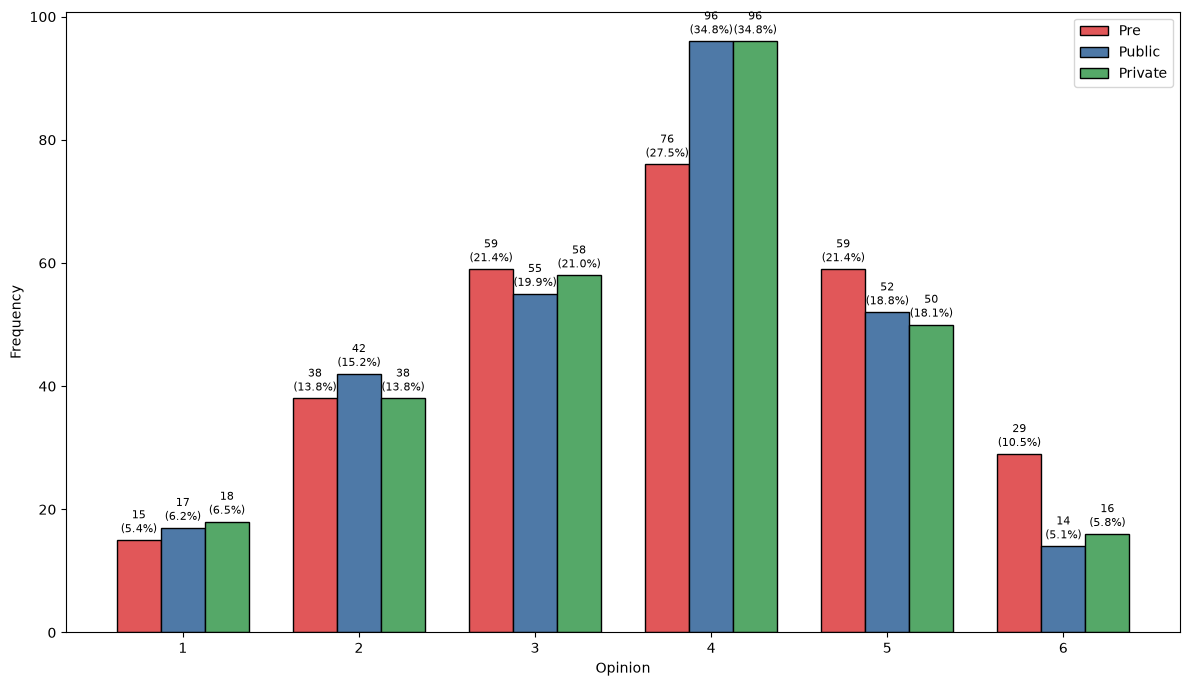

In [25]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
stmt_ids = [1, 2, 3, 4, 5, 6]

pre = []
public = []
priv = []
for row in data:
    for sid in stmt_ids:
        if(row["topic"] == "socio-economic"):
            pre.append(int(row["pre_" + str(sid)]))
            public.append(int(row["public_" + str(sid)]))
            priv.append(int(row["priv_" + str(sid)]))

# valores possíveis
valores = [1, 2, 3, 4, 5, 6]

# contar frequências de cada valor em cada lista
pre_counts = [pre.count(v) for v in valores]
public_counts = [public.count(v) for v in valores]
priv_counts = [priv.count(v) for v in valores]

# totais para calcular percentagens
total_pre = len(pre)
total_public = len(public)
total_priv = len(priv)

# posições das barras
x = np.arange(len(valores))
largura = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

barras_pre = ax.bar(x - largura, pre_counts, width=largura, edgecolor="black", label="Pre", color="#E15759")
barras_public = ax.bar(x, public_counts, width=largura, edgecolor="black", label="Public", color="#4E79A7")
barras_priv = ax.bar(x + largura, priv_counts, width=largura, edgecolor="black", label="Private", color="#55A868")



ax.set_xlabel("Opinion")
ax.set_ylabel("Frequency")
ax.set_xticks(x)
ax.set_xticklabels(valores)
ax.legend()

# função para adicionar rótulos com número e percentagem
def adicionar_rotulos(barras, counts, total):
    for barra, count in zip(barras, counts):
        altura = barra.get_height()
        pct = 100 * count / total if total > 0 else 0
        ax.annotate(
            f"{count}\n({pct:.1f}%)",
            xy=(barra.get_x() + barra.get_width() / 2, altura),
            xytext=(0, 3),  # deslocamento vertical em pontos
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=8
        )

adicionar_rotulos(barras_pre, pre_counts, total_pre)
adicionar_rotulos(barras_public, public_counts, total_public)
adicionar_rotulos(barras_priv, priv_counts, total_priv)

plt.tight_layout()
plt.show()

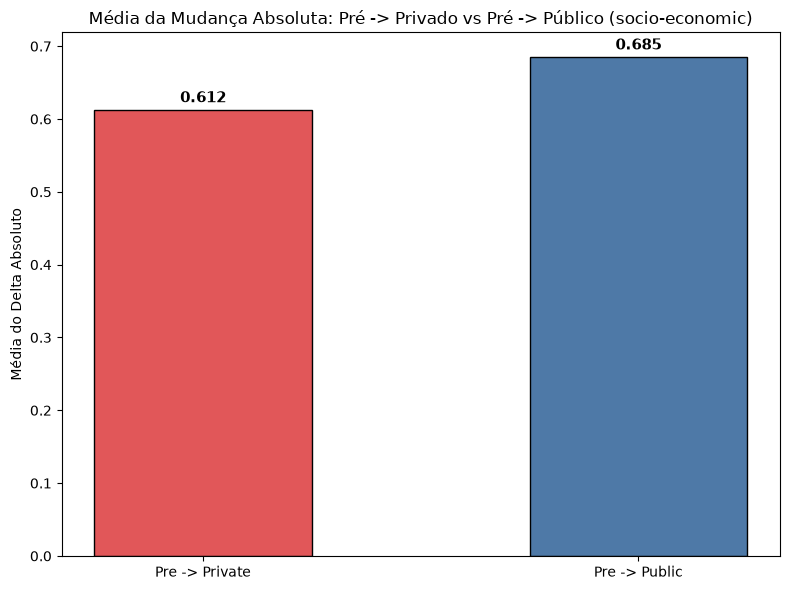

In [135]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
stmt_ids = [1, 2, 3, 4, 5, 6]

participants_delta_public_pre = []
participants_delta_priv_pre = []
for row in data:
    for sid in stmt_ids:
        if row["topic"] == "socio-economic":
            participants_delta_priv_pre.append(int(row["delta_pre_priv_" + str(sid)]))
            participants_delta_public_pre.append(int(row["delta_pre_public_" + str(sid)]))

means = {
    "Pre -> Private": np.mean(np.abs(participants_delta_priv_pre)),
    "Pre -> Public": np.mean(np.abs(participants_delta_public_pre))
}

labels = list(means.keys())
valores = list(means.values())

fig, ax = plt.subplots(figsize=(8, 6))

barras = ax.bar(labels, valores, color=["#E15759", "#4E79A7"], edgecolor="black", width=0.5)



ax.set_ylabel("Média do Delta Absoluto")
ax.set_title("Média da Mudança Absoluta: Pré -> Privado vs Pré -> Público (socio-economic)")

# adicionar rótulo com o valor por cima de cada barra
for barra, valor in zip(barras, valores):
    altura = barra.get_height()
    ax.annotate(
        f"{valor:.3f}",
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )

plt.tight_layout()
plt.show()

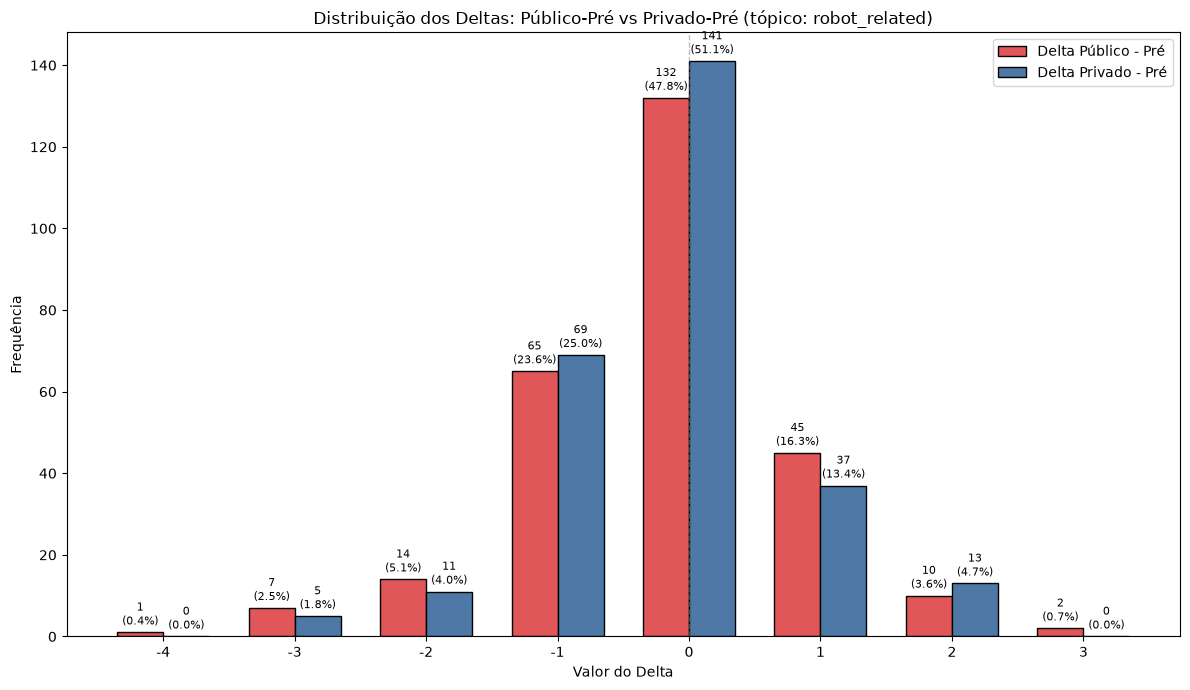

In [27]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
stmt_ids = [1, 2, 3, 4, 5, 6]

participants_delta_public_pre = []
participants_delta_priv_pre = []
for row in data:
    for sid in stmt_ids:
        if row["topic"] == "socio-economic":
            participants_delta_priv_pre.append(int(row["delta_pre_priv_" + str(sid)]))
            participants_delta_public_pre.append(int(row["delta_pre_public_" + str(sid)]))

# determinar todos os valores possíveis presentes nos dados (deltas podem ser negativos)
todos_valores = sorted(set(participants_delta_public_pre) | set(participants_delta_priv_pre))

# contar frequências de cada valor em cada lista
public_counts = [participants_delta_public_pre.count(v) for v in todos_valores]
priv_counts = [participants_delta_priv_pre.count(v) for v in todos_valores]

# totais para calcular percentagens
total_public = len(participants_delta_public_pre)
total_priv = len(participants_delta_priv_pre)

# posições das barras
x = np.arange(len(todos_valores))
largura = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

barras_public = ax.bar(x - largura/2, public_counts, edgecolor="black", width=largura, label="Delta Público - Pré", color="#E15759")
barras_priv = ax.bar(x + largura/2, priv_counts, edgecolor="black", width=largura, label="Delta Privado - Pré", color="#4E79A7")



ax.set_xlabel("Valor do Delta")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição dos Deltas: Público-Pré vs Privado-Pré (tópico: robot_related)")
ax.set_xticks(x)
ax.set_xticklabels(todos_valores)
ax.axvline(x=np.where(np.array(todos_valores) == 0)[0][0] if 0 in todos_valores else None,
           color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.legend()

# função para adicionar rótulos com número e percentagem
def adicionar_rotulos(barras, counts, total):
    for barra, count in zip(barras, counts):
        altura = barra.get_height()
        pct = 100 * count / total if total > 0 else 0
        ax.annotate(
            f"{count}\n({pct:.1f}%)",
            xy=(barra.get_x() + barra.get_width() / 2, altura),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=8
        )

adicionar_rotulos(barras_public, public_counts, total_public)
adicionar_rotulos(barras_priv, priv_counts, total_priv)

plt.tight_layout()
plt.savefig("histograma_deltas.png", dpi=150)
plt.show()

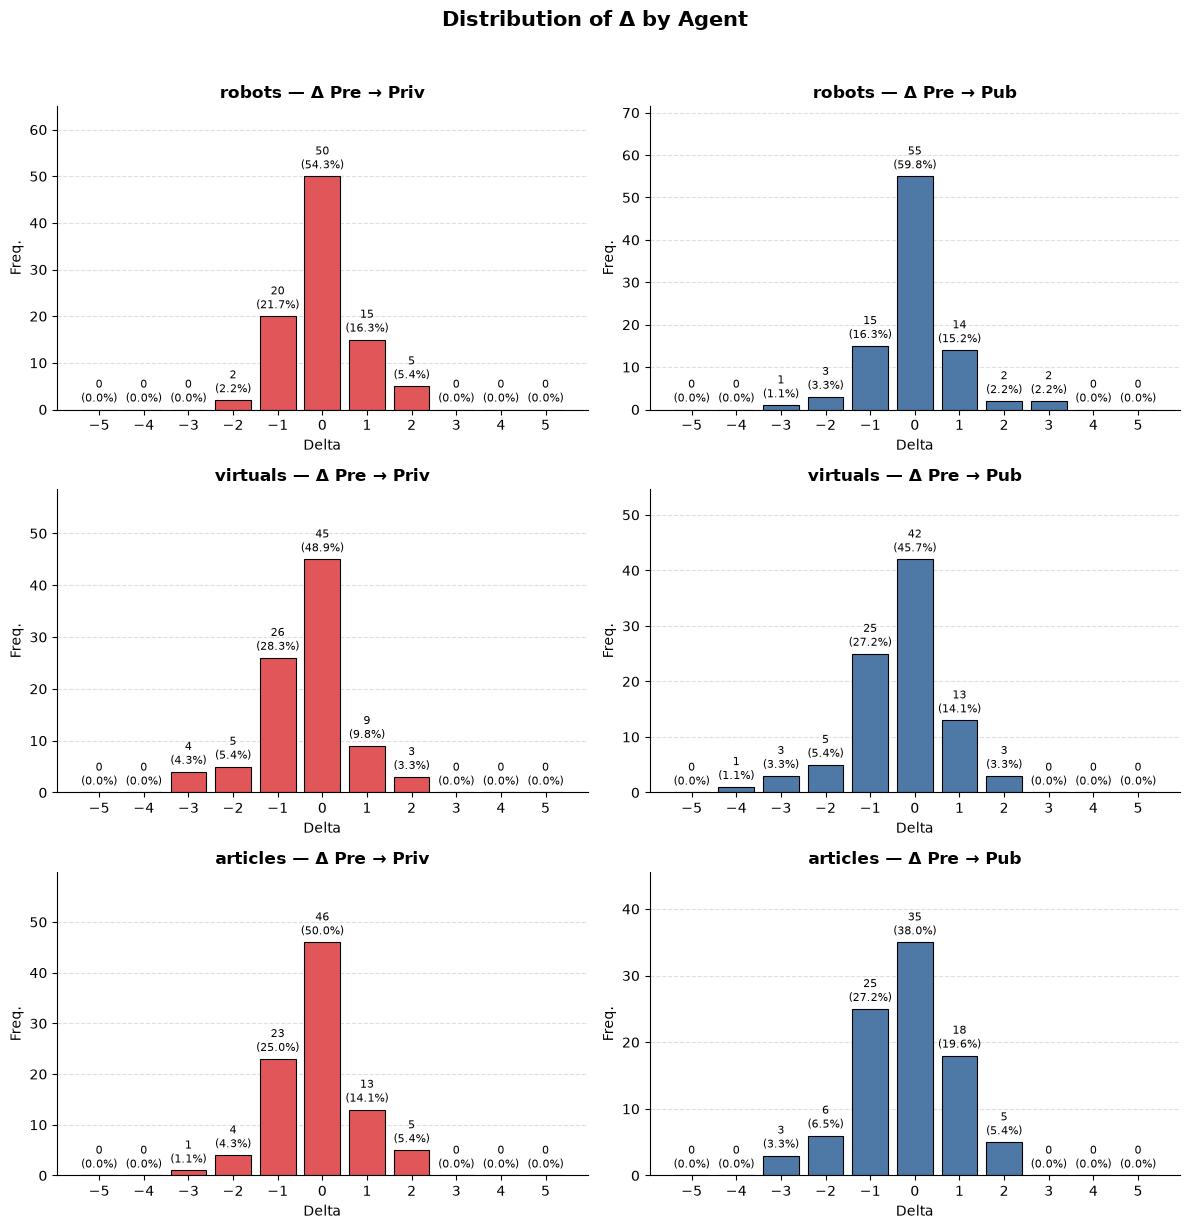

In [29]:
import json
import pandas as pd
import numpy as np

with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
stmt_ids = [1, 2, 3, 4, 5, 6]

pre_public = []
pre_priv = []

    

for ag in agents:
    pre_priv_aux = []
    pre_public_aux = []
    for row in data:
        for sid in stmt_ids:
            if(row["agents_"+str(sid)] == ag and row["topic"] == "socio-economic"):
                pre_priv_aux.append(int(row["delta_pre_priv_"+str(sid)]))
                pre_public_aux.append(int(row["delta_pre_public_"+str(sid)]))

    pre_public.append(pre_public_aux)
    pre_priv.append(pre_priv_aux)

lo, hi = -5, 5
bins = range(lo, hi + 2)

fig, axes = plt.subplots(len(agents), 2, figsize=(12, 4 * len(agents)))

cor_public = "#4E79A7"
cor_priv = "#E15759"


for i, ag in enumerate(agents):
    pre_public_ag = pre_public[i]
    pre_priv_ag = pre_priv[i]


    for j, (nome, valores, cor) in enumerate([
        
        ("Pre → Priv", pre_priv_ag, cor_priv),
        ("Pre → Pub", pre_public_ag, cor_public),
    ]):
        ax = axes[i, j]
        counts, edges, patches = ax.hist(
            valores, bins=bins, align="left", rwidth=0.8,
            color=cor, edgecolor="black", linewidth=0.8
        )
        total = len(valores)
        labels = [f"{int(c)}\n({c/total*100:.1f}%)" if total > 0 else "0" for c in counts]
        ax.bar_label(patches, labels=labels, padding=3, fontsize=8)

        ax.set_title(f"{ag} — Δ {nome}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Delta")
        ax.set_ylabel("Freq.")
        ax.set_xticks(range(lo, hi + 1))
        ax.set_ylim(0, max(counts) * 1.3 if len(counts) else 1)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.set_axisbelow(True)

fig.suptitle("Distribution of Δ by Agent", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Calculate the model variables

In [30]:
def susceptibility(pre, delta_priv_pre):
    lim = 0
    if(pre > 3.5):
        s = -1
    else:
        s = 1
    if(delta_priv_pre > 0):
        lim = 6
    else:
        lim = 1

    #print("susc = " + str(s) +" (" + str(row["delta_pre_priv_"+str(sid)]) + "/(|" + str(lim) + " - " + str(row["pre_"+str(sid)]) +"|))")
    #print(row["participant_id"])
    #print(lim)
    #print(row["pre_"+str(sid)])
    #print(row["priv_"+str(sid)])
    if(delta_priv_pre!= 0):
        return (s*delta_priv_pre/np.abs(lim - pre))
    else:
        return 0

In [31]:
print(susceptibility(4, 1))

-0.5


In [32]:
def conformity(pre, delta_public_pre):
    lim = 0
    if(pre > 3.5):
        s = -1
    else:
        s = 1
    if(delta_public_pre > 0):
        lim = 6
    else:
        lim = 1

    #print("susc = " + str(s) +" (" + str(row["delta_pre_priv_"+str(sid)]) + "/(|" + str(lim) + " - " + row["pre_"+str(sid)] +"|))")
    #print(lim)
    #print(row["pre_"+str(sid)])
    if(delta_public_pre!= 0):
        return (s*int(delta_public_pre)/np.abs(lim - pre))
    else:
        return 0

### Robot_related

#### __Susceptibility__

In [36]:
import json
import pandas as pd
import numpy as np

with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
stmt_ids = [1, 2, 3, 4, 5, 6]



for ag in agents:
    susc = 0
    total = 0
        
    for row in data:
        for sid in stmt_ids:
            if(row["agents_"+str(sid)] == ag and row["condition_"+str(sid)] == "all_disagree" and row["topic"] == "robot_related"):
                susc += susceptibility(int(row["pre_"+str(sid)]), int(row["delta_pre_priv_"+str(sid)]))
                total += 1

    susc = susc/(total*4)
    print("Agent: " + ag + " - Susc: " + str(susc))

                    
                                                               
                    

Agent: robots - Susc: 0.04628623188405796
Agent: virtuals - Susc: 0.02817028985507247
Agent: articles - Susc: 0.014764492753623184


#### __Weight__

sid:1
pid:15
3
0
3

sid:3
pid:51
2
1
3

sid:1
pid:82
3
1
4



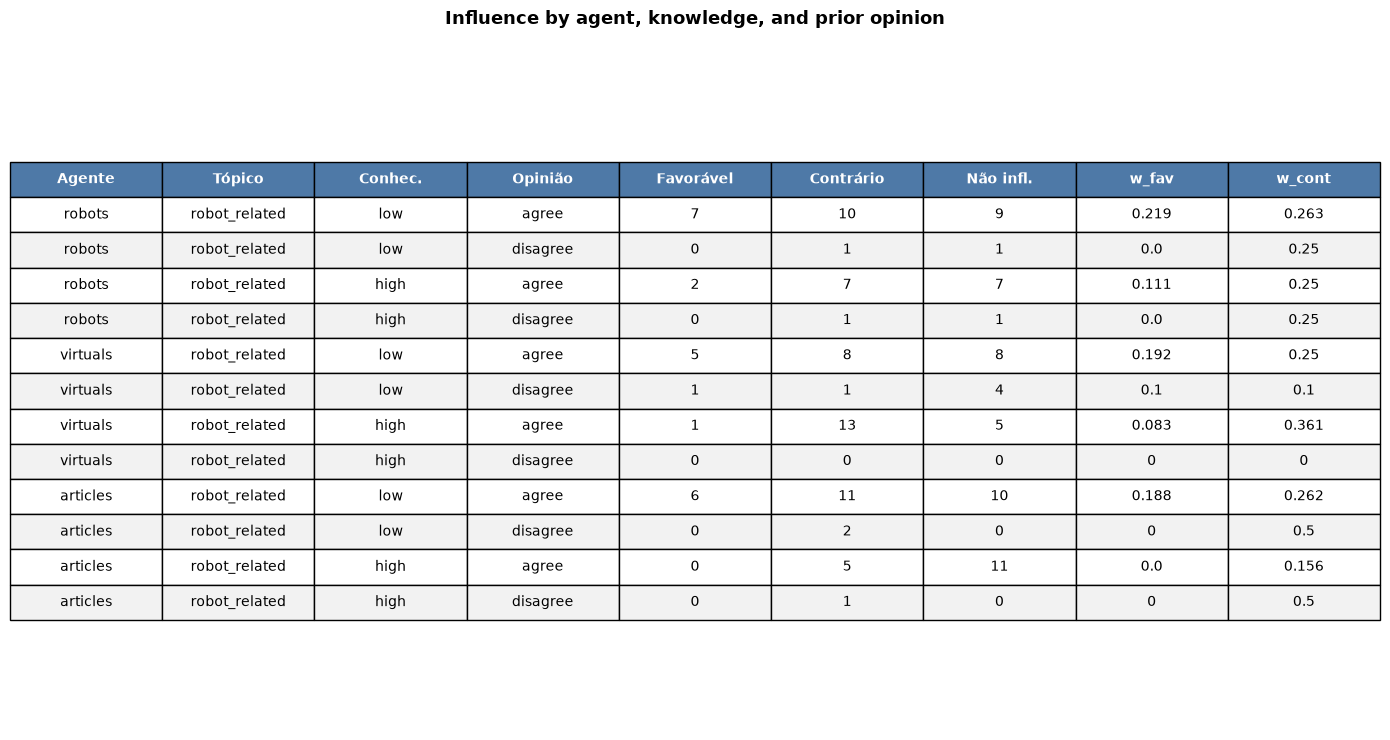

In [39]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
topics = ["robot_related"]
knowledge = ["low", "high"]
opinion_human = ["agree", "disagree"]
opinion_agent = ["favorable", "contrary"]

dic = {}


stmt_ids = [1, 2, 3, 4, 5, 6]

rows = []

#print("Agent - Topic - Kn - oh - Fav - Cont - NotInf - w_fav - w_cont")

pro_ids = []
anti_ids = []

for row in data:
    pre = []
    for sid in stmt_ids:
        pre.append(int(row["pre_" + str(sid)]))
    mean = np.mean(pre)
    if mean >= 3.5:
        pro_ids.append(row["participant_id"])
    else:
        anti_ids.append(row["participant_id"])


for t in topics:
    for ag in agents:
        for kn in knowledge:
            for oh in opinion_human:   

                    n_favorable = 0
                    n_notinfluenced = 0
                    n_contrary = 0
                    
        
        
                    for row in data:
                    
                        for sid in stmt_ids:
                            if(row["agents_"+str(sid)] == ag and row["topic"] == t and row["condition_"+str(sid)] == "half_disagree"):
                                
                                
                                if(kn == "low" and int(row["knowledge_"+str(sid)]) <= 4):

                                    if(int(row["pre_"+str(sid)]) < 3.5 and oh == "disagree"):
                                        if int(row["delta_pre_priv_"+str(sid)]) < 0:
                                            n_favorable +=1
                                        elif int(row["delta_pre_priv_"+str(sid)]) > 0:
                                            n_contrary +=1
                                        else:
                                            n_notinfluenced +=1
                                    elif(int(row["pre_"+str(sid)]) >= 3.5 and oh == "agree"):
                                        if int(row["delta_pre_priv_"+str(sid)]) > 0:
                                            n_favorable +=1
                                        elif int(row["delta_pre_priv_"+str(sid)]) < 0:
                                            n_contrary +=1
                                        else:
                                            n_notinfluenced +=1

                                elif(kn == "high" and int(row["knowledge_"+str(sid)]) > 4):
                                    if(int(row["pre_"+str(sid)]) < 3.5 and oh == "disagree"):
                                        print("sid:"+str(sid))
                                        print("pid:"+row["participant_id"])
                                        print(int(row["pre_"+str(sid)]))
                                        print(int(row["delta_pre_priv_"+str(sid)]))
                                        print(int(row["priv_"+str(sid)]))
                                        print()
                                        if int(row["delta_pre_priv_"+str(sid)]) < 0:
                                            n_favorable +=1
                                        elif int(row["delta_pre_priv_"+str(sid)])  > 0:
                                            n_contrary +=1
                                        else:
                                            n_notinfluenced +=1
                                    elif(int(row["pre_"+str(sid)]) >= 3.5 and oh == "agree"):
                                        
                                        if int(row["delta_pre_priv_"+str(sid)]) > 0:
                                            n_favorable +=1
                                        elif int(row["delta_pre_priv_"+str(sid)]) < 0:
                                            n_contrary +=1
                                        else:
                                            n_notinfluenced +=1
                    if(n_favorable+n_notinfluenced !=0):
                        w_fav = n_favorable/(2*(n_favorable+n_notinfluenced))
                    else:
                        w_fav = 0
                    if(n_contrary+n_notinfluenced != 0):
                        w_cont = n_contrary/(2*(n_contrary+n_notinfluenced))
                    else:
                        w_cont = 0
                    
                    rows.append([ag, t, kn, oh, n_favorable, n_contrary, n_notinfluenced,
                             round(w_fav, 3), round(w_cont, 3)])

# ---- plot da tabela ----
col_labels = ["Agente", "Tópico", "Conhec.", "Opinião", "Favorável",
              "Contrário", "Não infl.", "w_fav", "w_cont"]

fig, ax = plt.subplots(figsize=(14, 0.5 * len(rows) + 1.5))
ax.axis("off")

table = ax.table(cellText=rows, colLabels=col_labels, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# cabeçalho estilizado
for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_facecolor("#4E79A7")
    cell.set_text_props(color="white", fontweight="bold")

# linhas alternadas
for i in range(1, len(rows) + 1):
    for j in range(len(col_labels)):
        cell = table[i, j]
        cell.set_facecolor("#F2F2F2" if i % 2 == 0 else "white")

ax.set_title("Influence by agent, knowledge, and prior opinion",
              fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

#### __Conformity__

In [37]:
import json
import pandas as pd
import numpy as np

with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
topics = [ "robot_related"]
stmt_ids = [1, 2, 3, 4, 5, 6]



for ag in agents:
    for t in topics:
        conf = 0
        total = 0
        
        for row in data:
            for sid in stmt_ids:
                if(row["agents_"+str(sid)] == ag and row["topic"] == t and row["condition_"+str(sid)] == "all_disagree" and row["topic"] == "robot_related"):
                    conf += conformity(int(row["pre_"+str(sid)]), int(row["delta_pre_public_"+str(sid)]))
                    total += 1

        conf = conf/(4*total)
        print("Agent: " + ag + " - Topic: "+ t +" - Conf: " + str(conf))

                    
                                                               
                    

Agent: robots - Topic: robot_related - Conf: 0.05697463768115942
Agent: virtuals - Topic: robot_related - Conf: 0.04465579710144928
Agent: articles - Topic: robot_related - Conf: 0.02590579710144928


### Socio-economic

#### __Susceptibility__

In [10]:
import json
import pandas as pd
import numpy as np

with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
stmt_ids = [1, 2, 3, 4, 5, 6]



for ag in agents:
    susc = 0
    total = 0
        
    for row in data:
        for sid in stmt_ids:
            if(row["topic"] == "socio-economic" and row["agents_"+str(sid)] == ag and row["condition_"+str(sid)] == "all_disagree"):
                susc += susceptibility(int(row["pre_"+str(sid)]), int(row["delta_pre_priv_"+str(sid)]))
                total += 1

    susc = susc/(total*4)
    print("Agent: " + ag + " - Susc: " + str(susc))

                    
                                                               
                    

Agent: robots - Susc: 0.026902173913043483
Agent: virtuals - Susc: 0.04347826086956521
Agent: articles - Susc: 0.05344202898550725


#### __Weight__

sid:4
pid:4
1
0
1

sid:2
pid:10
2
1
3

sid:6
pid:32
1
0
1

sid:2
pid:38
1
1
2

sid:4
pid:52
3
0
3

sid:4
pid:68
2
-1
1

sid:2
pid:78
2
0
2

sid:2
pid:84
3
0
3

sid:6
pid:6
1
0
1

sid:3
pid:8
2
0
2

sid:2
pid:12
2
-1
1

sid:1
pid:22
1
1
2

sid:4
pid:20
3
-1
2

sid:1
pid:44
2
0
2

sid:1
pid:52
3
0
3

sid:4
pid:54
3
-1
2



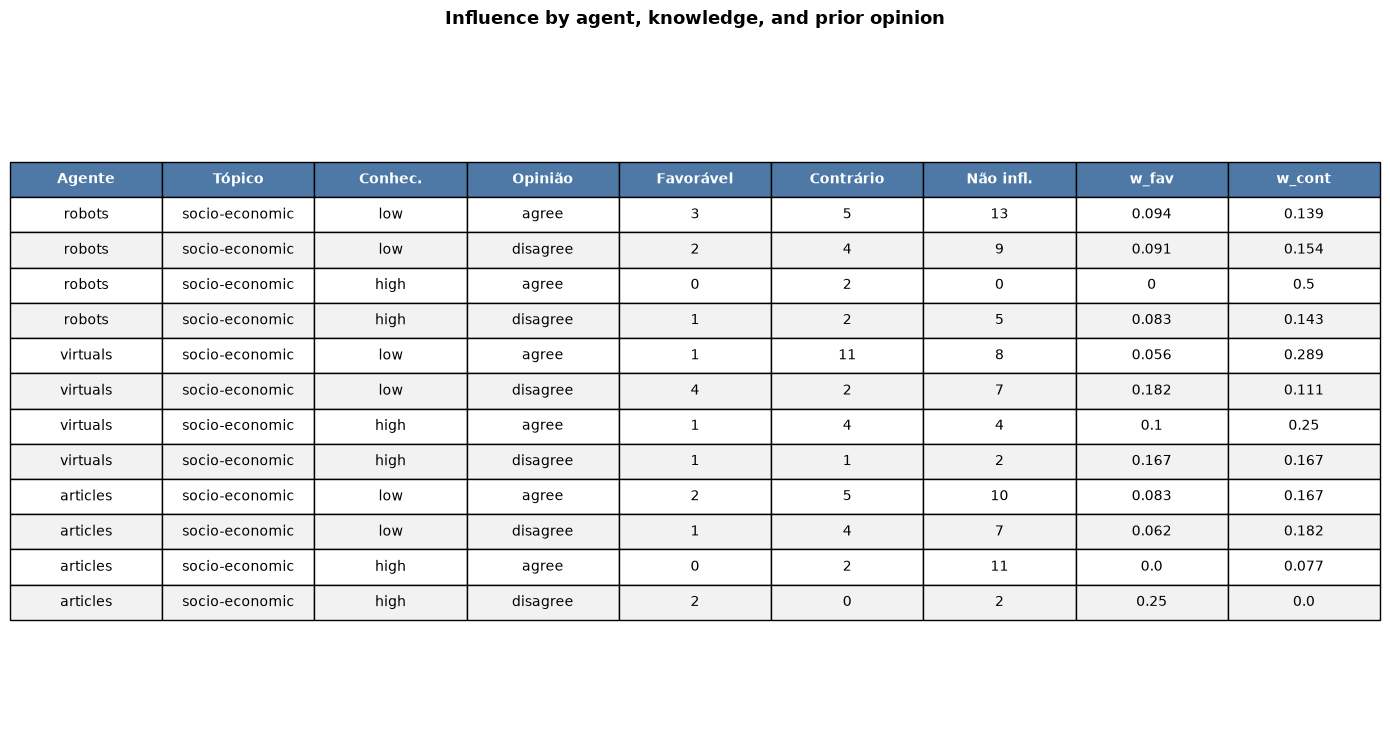

In [42]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
topics = ["socio-economic"]
knowledge = ["low", "high"]
opinion_human = ["agree", "disagree"]
opinion_agent = ["favorable", "contrary"]

dic = {}


stmt_ids = [1, 2, 3, 4, 5, 6]

rows = []



for t in topics:
    for ag in agents:
        for kn in knowledge:
            for oh in opinion_human:   

                    n_favorable = 0
                    n_notinfluenced = 0
                    n_contrary = 0
                    
        
        
                    for row in data:
                    
                        for sid in stmt_ids:
                            if(row["agents_"+str(sid)] == ag and row["topic"] == t and row["condition_"+str(sid)] == "half_disagree"):
                                
                                
                                if(kn == "low" and int(row["knowledge_"+str(sid)]) <= 4):

                                    if(int(row["pre_"+str(sid)]) < 3.5 and oh == "disagree"):
                                        if int(row["delta_pre_priv_"+str(sid)]) < 0:
                                            n_favorable +=1
                                        elif int(row["delta_pre_priv_"+str(sid)]) > 0:
                                            n_contrary +=1
                                        else:
                                            n_notinfluenced +=1
                                    elif(int(row["pre_"+str(sid)]) >= 3.5 and oh == "agree"):
                                        if int(row["delta_pre_priv_"+str(sid)]) > 0:
                                            n_favorable +=1
                                        elif int(row["delta_pre_priv_"+str(sid)]) < 0:
                                            n_contrary +=1
                                        else:
                                            n_notinfluenced +=1

                                elif(kn == "high" and int(row["knowledge_"+str(sid)]) > 4):
                                    if(int(row["pre_"+str(sid)]) < 3.5 and oh == "disagree"):
                                        print("sid:"+str(sid))
                                        print("pid:"+row["participant_id"])
                                        print(int(row["pre_"+str(sid)]))
                                        print(int(row["delta_pre_priv_"+str(sid)]))
                                        print(int(row["priv_"+str(sid)]))
                                        print()
                                        if int(row["delta_pre_priv_"+str(sid)]) < 0:
                                            n_favorable +=1
                                        elif int(row["delta_pre_priv_"+str(sid)])  > 0:
                                            n_contrary +=1
                                        else:
                                            n_notinfluenced +=1
                                    elif(int(row["pre_"+str(sid)]) >= 3.5 and oh == "agree"):
                                        
                                        if int(row["delta_pre_priv_"+str(sid)]) > 0:
                                            n_favorable +=1
                                        elif int(row["delta_pre_priv_"+str(sid)]) < 0:
                                            n_contrary +=1
                                        else:
                                            n_notinfluenced +=1
                    if(n_favorable+n_notinfluenced !=0):
                        w_fav = n_favorable/(2*(n_favorable+n_notinfluenced))
                    else:
                        w_fav = 0
                    if(n_contrary+n_notinfluenced != 0):
                        w_cont = n_contrary/(2*(n_contrary+n_notinfluenced))
                    else:
                        w_cont = 0
                    
                    rows.append([ag, t, kn, oh, n_favorable, n_contrary, n_notinfluenced,
                             round(w_fav, 3), round(w_cont, 3)])

# ---- plot da tabela ----
col_labels = ["Agente", "Tópico", "Conhec.", "Opinião", "Favorável",
              "Contrário", "Não infl.", "w_fav", "w_cont"]

fig, ax = plt.subplots(figsize=(14, 0.5 * len(rows) + 1.5))
ax.axis("off")

table = ax.table(cellText=rows, colLabels=col_labels, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# cabeçalho estilizado
for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_facecolor("#4E79A7")
    cell.set_text_props(color="white", fontweight="bold")

# linhas alternadas
for i in range(1, len(rows) + 1):
    for j in range(len(col_labels)):
        cell = table[i, j]
        cell.set_facecolor("#F2F2F2" if i % 2 == 0 else "white")

ax.set_title("Influence by agent, knowledge, and prior opinion",
              fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

#### __Conformity__

In [11]:
import json
import pandas as pd
import numpy as np

with open("./data_final.json") as f:
    data = json.load(f)

agents = ["robots", "virtuals", "articles"]
stmt_ids = [1, 2, 3, 4, 5, 6]



for ag in agents:
    conf = 0
    total = 0
        
    for row in data:
        for sid in stmt_ids:
            if(row["topic"] == "socio-economic" and row["agents_"+str(sid)] == ag and row["condition_"+str(sid)] == "all_disagree"):
                conf += conformity(int(row["pre_"+str(sid)]), int(row["delta_pre_public_"+str(sid)]))
                total += 1

    conf = conf/(4*total)
    print("Agent: " + ag +" - Conf: " + str(conf))


                    
                                                               
                    

Agent: robots - Conf: 0.021557971014492756
Agent: virtuals - Conf: 0.050724637681159424
Agent: articles - Conf: 0.05543478260869566


## EPO Model

### Equations

In [124]:
def priv(opinion, last_opinion, agents_opinion, susc, weights):
    n = len(agents_opinion)
    delta = sum(
        s * ((1 - w) * opinion + w * a - last_opinion)
        for s, w, a in zip(susc, weights, agents_opinion)
    ) / n
    return last_opinion + delta


def public(opinion, agents_opinion, conf):
    n = len(agents_opinion)
    delta = sum(
        c * (a - opinion)
        for c, a in zip(conf, agents_opinion)
    ) / n
    return opinion + delta

In [125]:
print(priv(2, 2, [6], [0.1], [0.3]))

2.12


In [126]:
print(public(2, [6], [0.4]))

3.6


### Aux Functions and classes

In [127]:
import numpy as np

class Human:
    def __init__(self, initial_opinion, knlowedge):
        self.inital_opinion = initial_opinion
        self.previous_opinion = initial_opinion
        self.private_opinion = initial_opinion
        self.public_opinion = 0
        self.knowledge = knlowedge

    def update_previous(self, prev):
        self.previous_opinion = prev
    
    def update_priv(self, priv):
        self.private_opinion = priv

    def update_public(self, pub):
        self.public_opinion = pub

    def get_priv(self):
        return self.private_opinion

    def get_previous(self):
        return self.previous_opinion

    def get_initial(self):
        return self.inital_opinion

    def get_public(self):
        return self.public_opinion

    def get_knowledge(self):
        return self.knowledge

    
        

class Agent:
    def __init__(self, opinion, type_inf, susc, conf):
        self.type_inf = type_inf
        self.susc = susc
        self.conf = conf
        self.opinion = opinion

    def get_opinion(self):
        return self.opinion

    def get_type(self):
        return self.type_inf

    def get_susc(self):
        return self.susc

    def get_conf(self):
        return self.conf
    
    

class Population:
    def __init__(self, topic, population_distribution, weights, susc, conf):
        self.population_humans = []
        self.population_influencer = []
        self.weights = weights
        self.susc = susc
        self.conf = conf
        self.topic = topic

        for _ in range(population_distribution["humans"]["number"]):
            opinion = np.random.choice(list(population_distribution["humans"]["opinions"].keys()), p=list(population_distribution["humans"]["opinions"].values()))
            kn = np.random.choice(list(population_distribution["humans"]["knowledge"].keys()), p=list(population_distribution["humans"]["knowledge"].values()))

            human = Human(int(opinion), kn)
            self.population_humans.append(human)

        
        for _ in range(population_distribution["influencers"]["article"]["number"]):
            opinion = np.random.choice(list(population_distribution["influencers"]["article"]["opinions"].keys()), p=list(population_distribution["influencers"]["article"]["opinions"].values()))
            s = float(susc["article"][topic]) 
            r = float(conf["article"][topic])
            new = Agent(int(opinion), "article", s, r)
            self.population_influencer.append(new)
        for _ in range(population_distribution["influencers"]["virtual"]["number"]):
            opinion = np.random.choice(list(population_distribution["influencers"]["virtual"]["opinions"].keys()), p=list(population_distribution["influencers"]["virtual"]["opinions"].values()))
            s = float(susc["virtual"][topic]) 
            r = float(conf["virtual"][topic])
            new = Agent(int(opinion), "virtual", s, r)
            self.population_influencer.append(new)
        for _ in range(population_distribution["influencers"]["robot"]["number"]):
            opinion = np.random.choice(list(population_distribution["influencers"]["robot"]["opinions"].keys()), p=list(population_distribution["influencers"]["robot"]["opinions"].values()))
            s = float(susc["robot"][topic]) 
            r = float(conf["robot"][topic])
            new = Agent(int(opinion), "robot", s, r)
            self.population_influencer.append(new)

        self.agents_public_opinions = []
        self.agents_confs = []
        self.agents_susc = []
        for i in self.population_influencer:
            self.agents_public_opinions.append(i.get_opinion())
            self.agents_confs.append(i.get_conf())
            self.agents_susc.append(i.get_susc())
        


            
    def step(self):
        for h in self.population_humans:

            h.update_public(public(h.get_priv(), self.agents_public_opinions, self.agents_confs))

        for h in self.population_humans:

            weights = []
             
            for i in self.population_influencer:
                
                inf_human_opinion = ""
                #print(h.get_priv())
                #print(i.get_opinion())
                if(h.get_priv() >= 3.5 and i.get_opinion() >= 3.5):
                    inf_human_opinion = "w_fav"
                elif(h.get_priv() >= 3.5 and i.get_opinion() < 3.5):
                    inf_human_opinion = "w_cont"
                elif(h.get_priv() < 3.5 and i.get_opinion() >= 3.5):
                    inf_human_opinion = "w_cont"
                elif(h.get_priv() < 3.5 and i.get_opinion() < 3.5):
                    inf_human_opinion = "w_fav"

                human_opinion = ""
               
                if(h.get_priv() >= 3.5):
                    human_opinion = "agree"
                else:
                    human_opinion = "disagree"

                #print(human_opinion)
                #print(inf_human_opinion)
                    
                
                weights.append(self.weights[i.get_type()][self.topic][h.get_knowledge()][human_opinion][inf_human_opinion])
                
            
            h.update_previous(h.get_priv())
            h.update_priv(priv(h.get_priv(), h.get_previous(), self.agents_public_opinions, self.agents_susc, weights))
                

    def get_public_opinions(self):
        opinions = []
        for h in self.population_humans:
            opinions.append(h.get_public())
            
        return opinions
    
    def get_priv_opinions(self):
        opinions = []
        for h in self.population_humans:
            opinions.append(h.get_priv())
            
        return opinions
        

        

### Weights, Susceptibility and Resilience dictionary

In [128]:
weights = {
    "robot": {
        "socio-economic": {
            "low": {
                "agree": {"w_fav": 0.094, "w_cont": 0.139},
                "disagree": {"w_fav": 0.091, "w_cont": 0.154}
            },
            "high": {
                "agree": {"w_fav": 0.0, "w_cont": 0.5},
                "disagree": {"w_fav": 0.083, "w_cont": 0.143}
            }
        },
        "robot_related": {
            "low": {
                "agree": {"w_fav": 0.219, "w_cont": 0.263},
                "disagree": {"w_fav": 0.0, "w_cont": 0.25}
            },
            "high": {
                "agree": {"w_fav": 0.111, "w_cont": 0.25},
                "disagree": {"w_fav": 0.0, "w_cont": 0.25}
            }
        }
    },
    "virtual": {
        "socio-economic": {
            "low": {
                "agree": {"w_fav": 0.056, "w_cont": 0.289},
                "disagree": {"w_fav": 0.182, "w_cont": 0.111}
            },
            "high": {
                "agree": {"w_fav": 0.1, "w_cont": 0.25},
                "disagree": {"w_fav": 0.167, "w_cont": 0.167}
            }
        },
        "robot_related": {
            "low": {
                "agree": {"w_fav": 0.192, "w_cont": 0.25},
                "disagree": {"w_fav": 0.1, "w_cont": 0.1}
            },
            "high": {
                "agree": {"w_fav": 0.083, "w_cont": 0.361},
                "disagree": {"w_fav": 0.0, "w_cont": 0.0}
            }
        }
    },
    "article": {
        "socio-economic": {
            "low": {
                "agree": {"w_fav": 0.083, "w_cont": 0.167},
                "disagree": {"w_fav": 0.062, "w_cont": 0.182}
            },
            "high": {
                "agree": {"w_fav": 0.0, "w_cont": 0.077},
                "disagree": {"w_fav": 0.25, "w_cont": 0.0}
            }
        },
        "robot_related": {
            "low": {
                "agree": {"w_fav": 0.188, "w_cont": 0.262},
                "disagree": {"w_fav": 0.0, "w_cont": 0.5}
            },
            "high": {
                "agree": {"w_fav": 0.0, "w_cont": 0.15},
                "disagree": {"w_fav": 0.0, "w_cont": 0.5}
            }
        }
    }
}

susc = { 
    "robot":{
        "socio-economic": 0.027,
        "robot_related": 0.046
    },
    "virtual":{
        "socio-economic": 0.043,
        "robot_related": 0.028
    },
    "article":{
        "socio-economic": 0.053,
        "robot_related": 0.015
    }
}



conf = { 
    "robot":{
        "socio-economic": 0.022,
        "robot_related": 0.057
    },
    "virtual":{
        "socio-economic": 0.051,
        "robot_related": 0.045
    },
    "article":{
        "socio-economic": 0.055,
        "robot_related": 0.026
    }
}



## Tests

### Robot Related

#### 1 Human vs 18 Robots

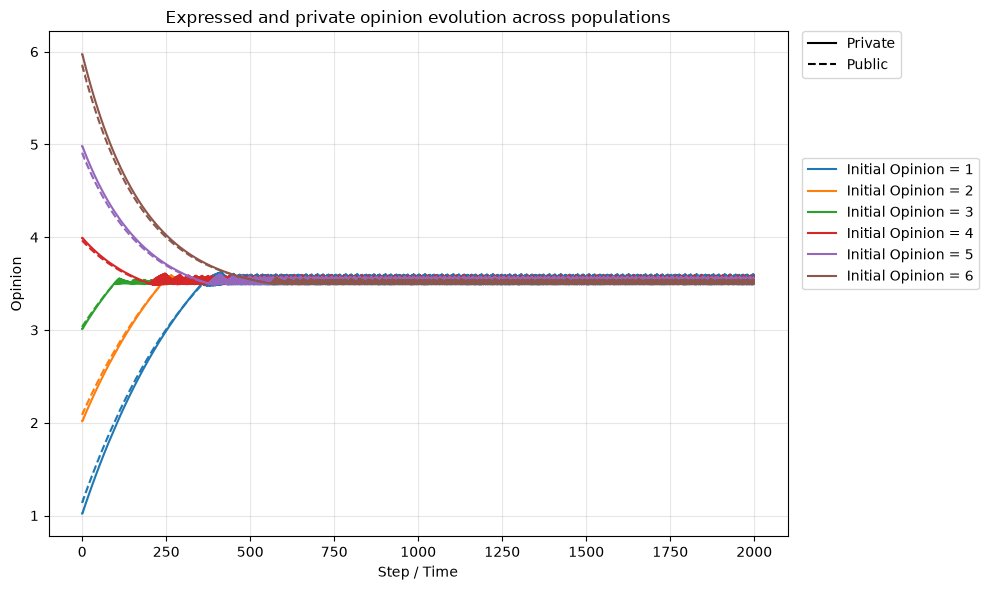

In [106]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 360,
                "opinions": { "1": 0.1666, "2": 0.1667, "3": 0.1667, "4": 0.1667, "5": 0.1667, "6": 0.1666 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("robot_related", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

Changes in human opinions when confronted with a group of 18 robots with uniformly distributed opinions

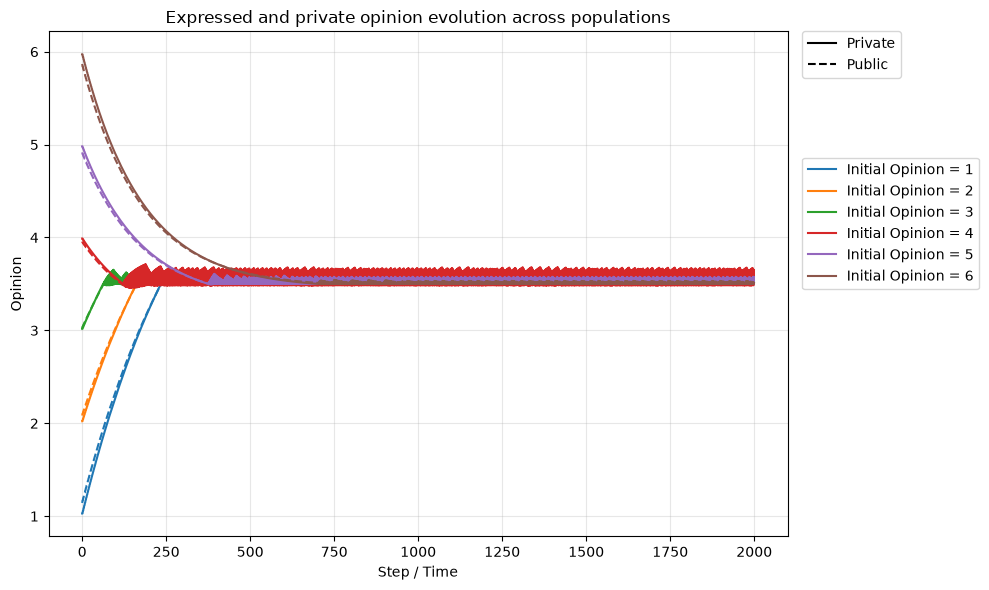

In [107]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 360,
                "opinions": { "1": 0.5, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0.5 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("robot_related", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

Changes in the opinions of humans when confronted with a group of 18 robots, with opinions distributed across extreme opinions (1 and 6).

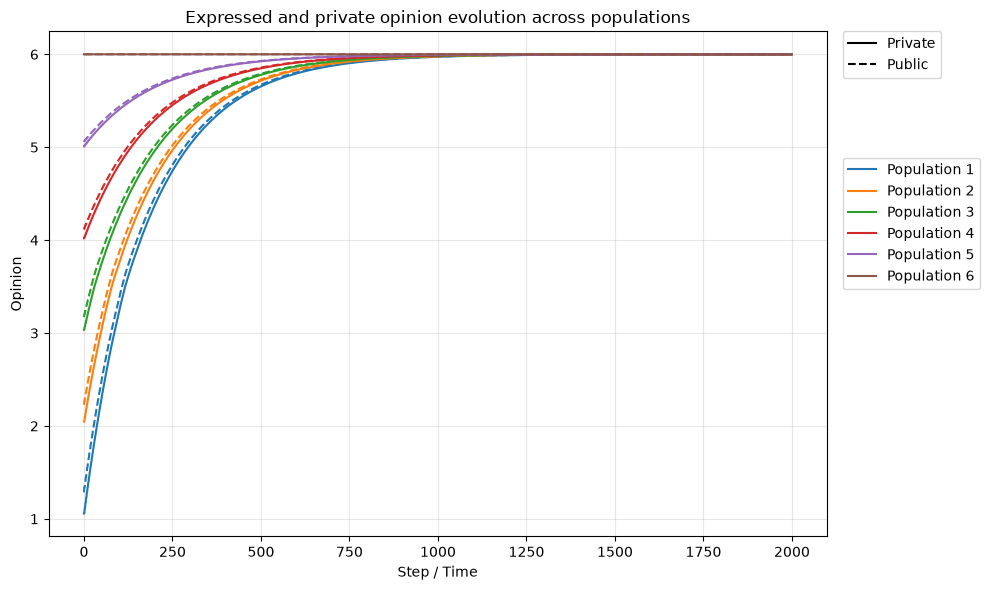

In [108]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 360,
                "opinions": { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("robot_related", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Population {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

Changes in the opinions of humans when confronted with a group of 18 robots, all with extreme pro-robot opinions

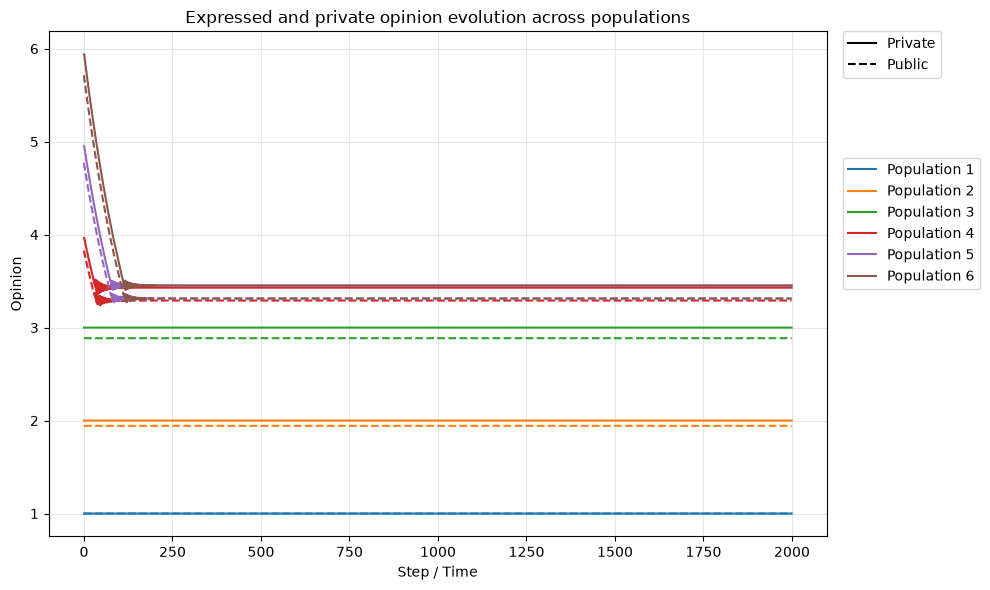

In [109]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 18,
                "opinions": { "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("robot_related", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Population {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

Changes in the opinions of humans when confronted with a group of 18 robots, all with extreme anti-robot opinions

#### 1 Human vs 18 Virtual agents

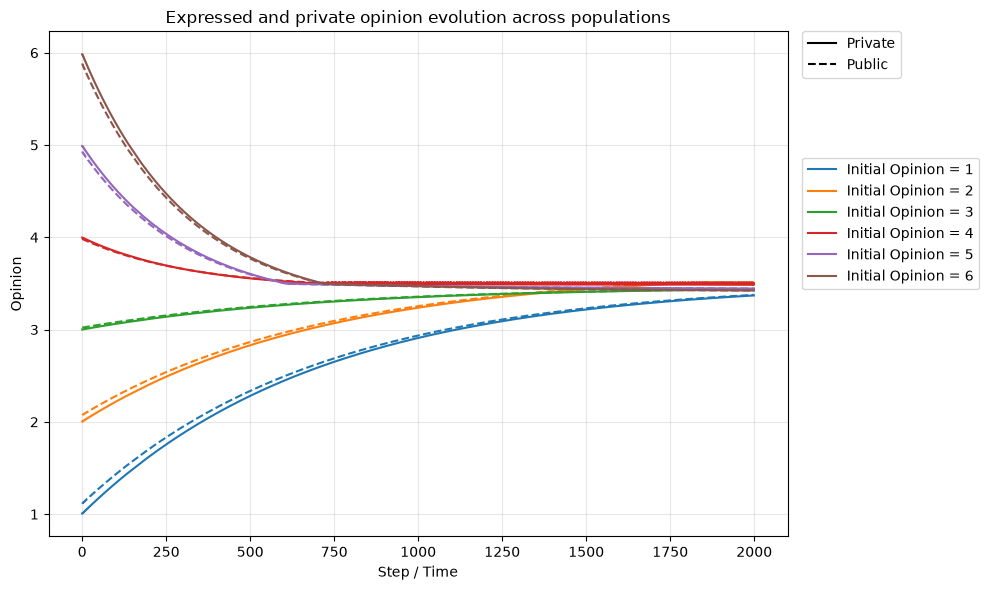

In [110]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            },
            "virtual": {
                "number": 360,
                "opinions": { "1": 0.1666, "2": 0.1667, "3": 0.1667, "4": 0.1667, "5": 0.1667, "6": 0.1666}
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("robot_related", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

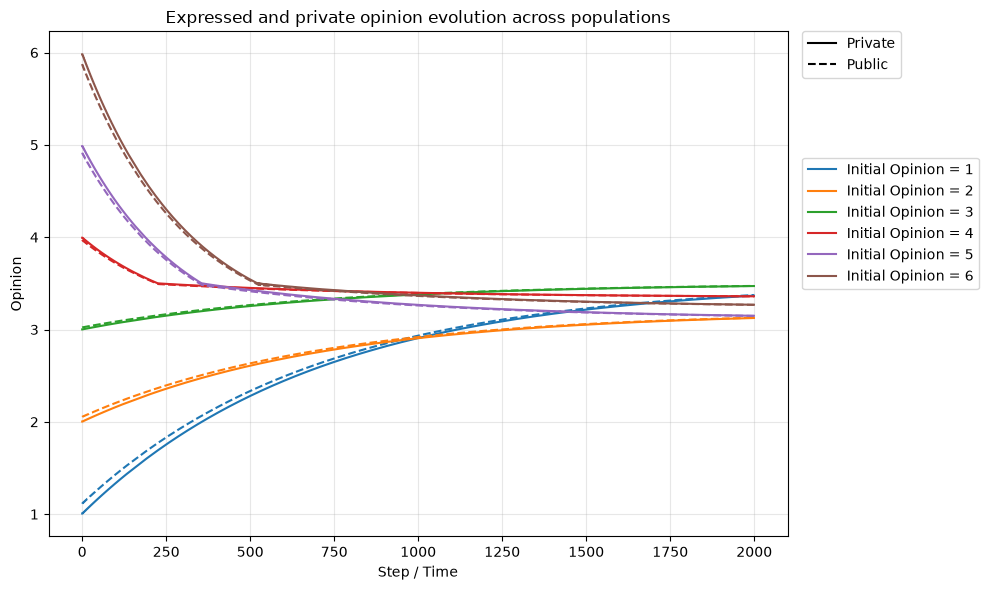

In [111]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            },
            "virtual": {
                "number": 360,
                "opinions": { "1": 0.5, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 0.5}
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("robot_related", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

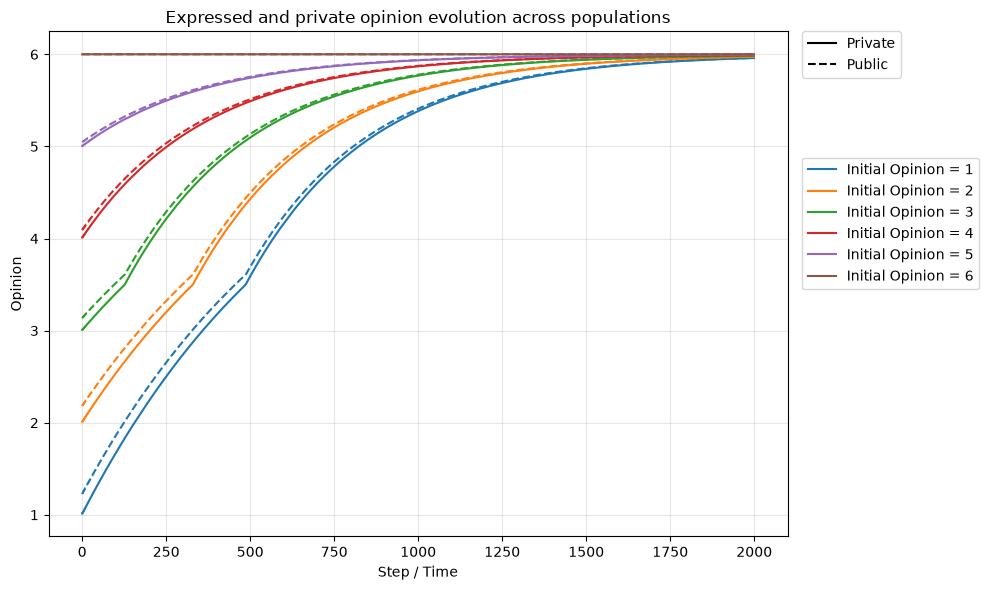

In [112]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            },
            "virtual": {
                "number": 360,
                "opinions": { "1": 0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1}
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("robot_related", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

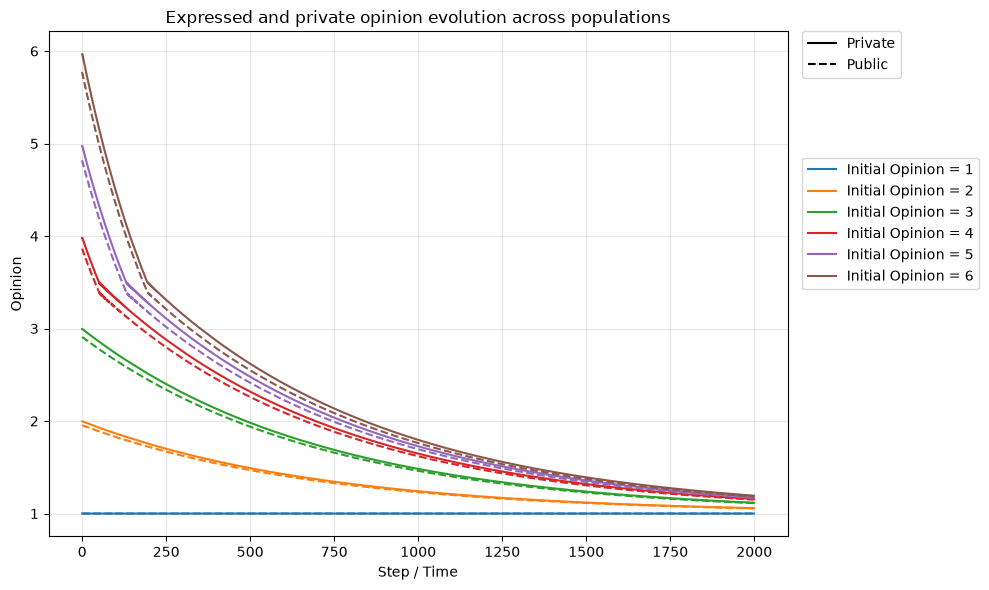

In [113]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            },
            "virtual": {
                "number": 360,
                "opinions": { "1": 1, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 0}
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("robot_related", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

#### 1 Human vs 18 News articles

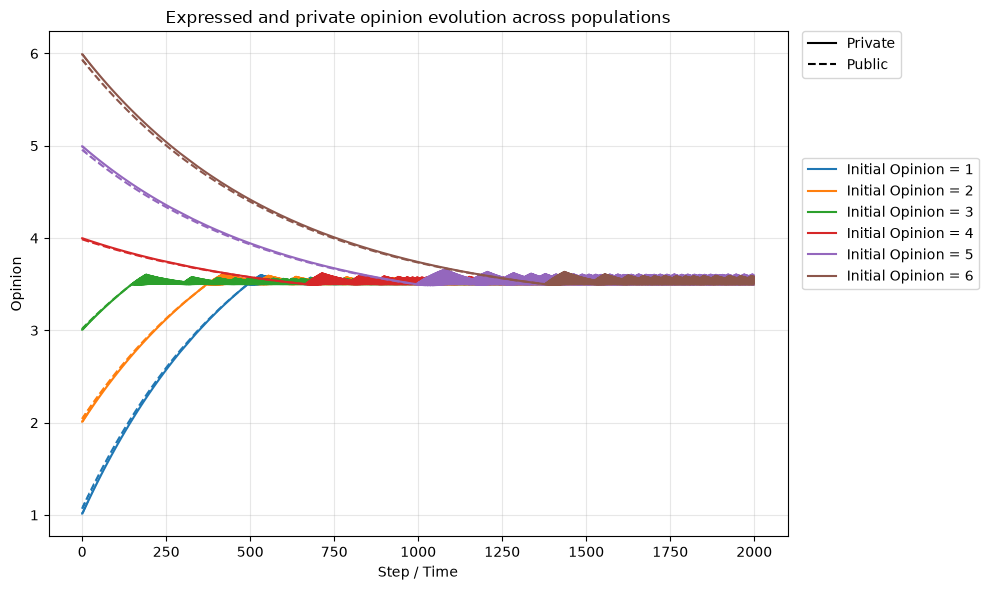

In [114]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            },
            "article": {
                "number": 360,
                "opinions": { "1": 0.1666, "2": 0.1667, "3": 0.1667, "4": 0.1667, "5": 0.1667, "6": 0.1666 }
            }
        }
    }
    populations.append(Population("robot_related", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

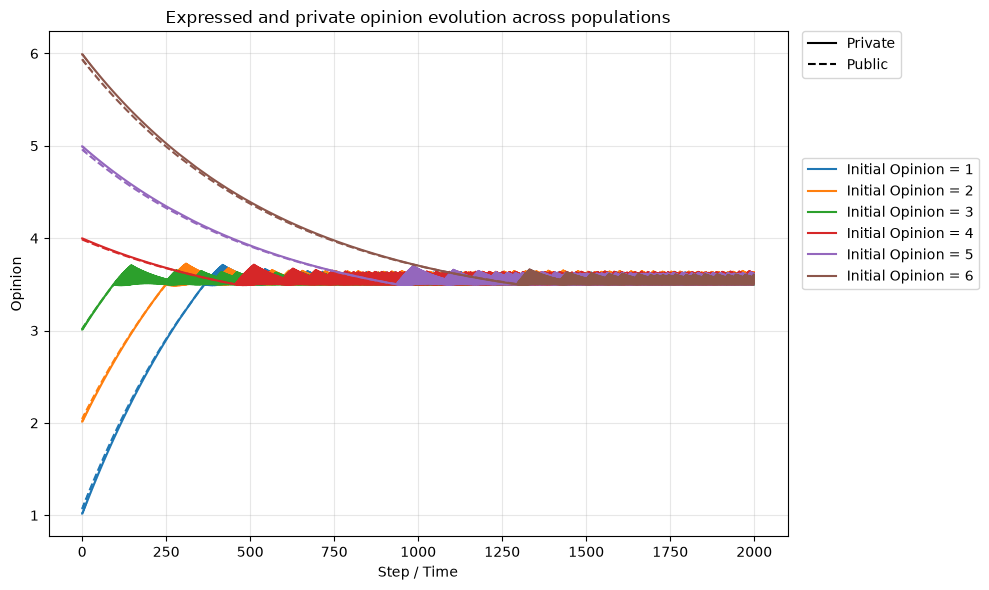

In [115]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            },
            "article": {
                "number": 360,
                "opinions": { "1": 0.5, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 0.5 }
            }
        }
    }
    populations.append(Population("robot_related", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

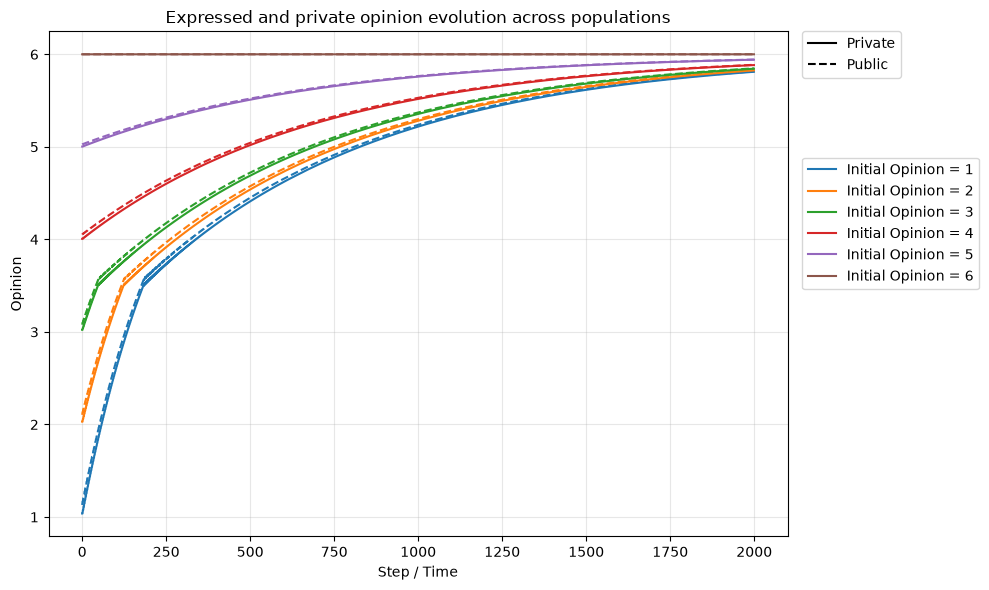

In [116]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            },
            "article": {
                "number": 360,
                "opinions": { "1": 0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1 }
            }
        }
    }
    populations.append(Population("robot_related", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

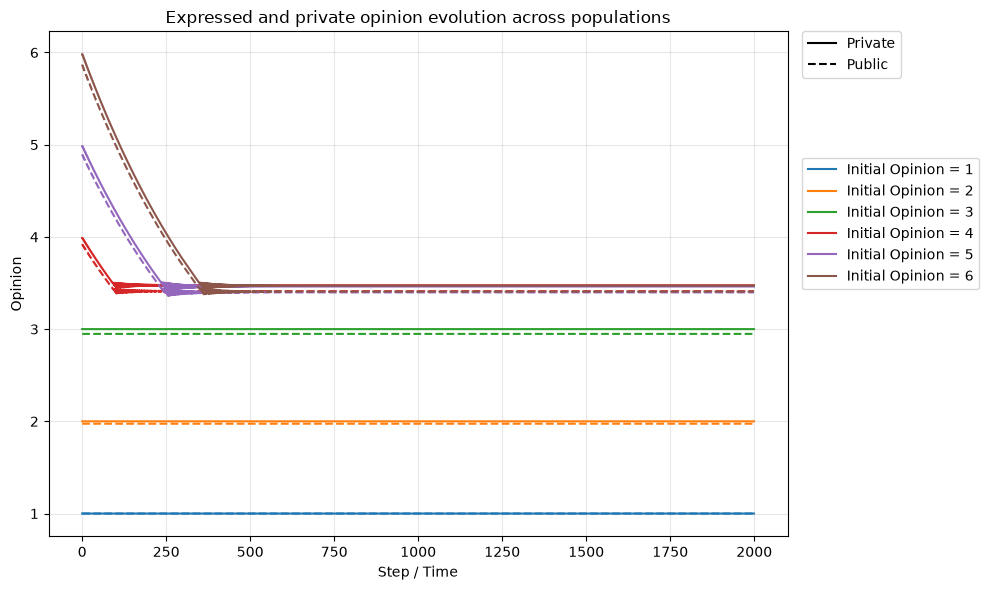

In [117]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            },
            "article": {
                "number": 360,
                "opinions": { "1": 1, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 0 }
            }
        }
    }
    populations.append(Population("robot_related", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

### Socio-economic


#### 1 Human vs 360 robots

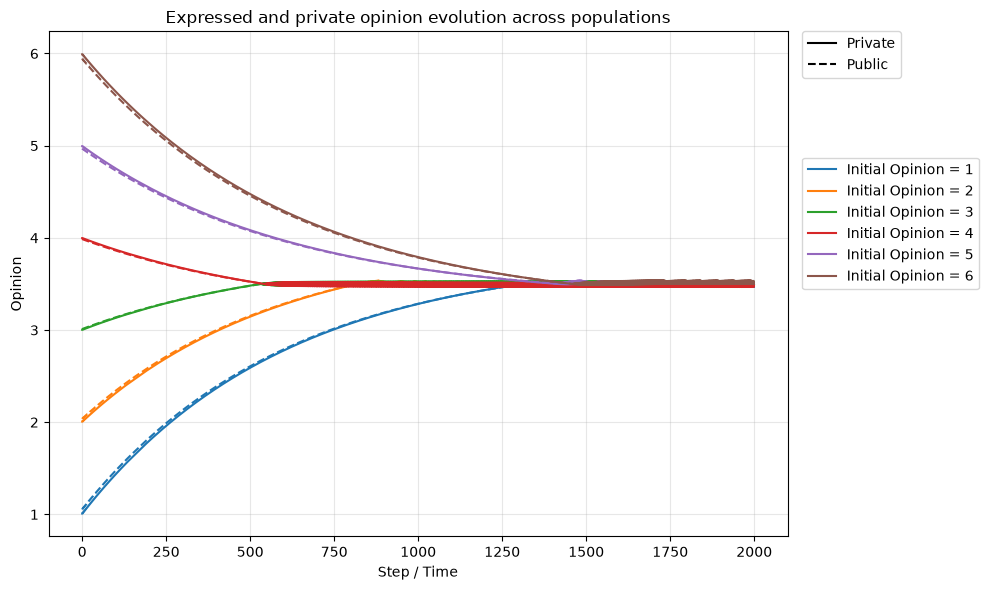

In [118]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 360,
                "opinions": { "1": 0.1666, "2": 0.1667, "3": 0.1667, "4": 0.1667, "5": 0.1667, "6": 0.1666 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("socio-economic", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

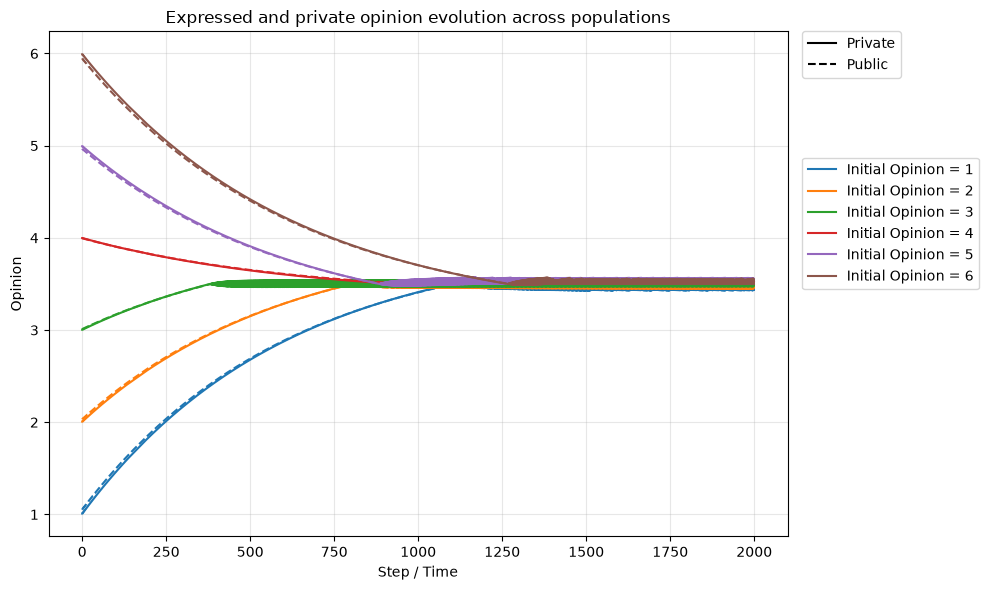

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 360,
                "opinions": { "1": 0.5, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 0.5 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("socio-economic", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

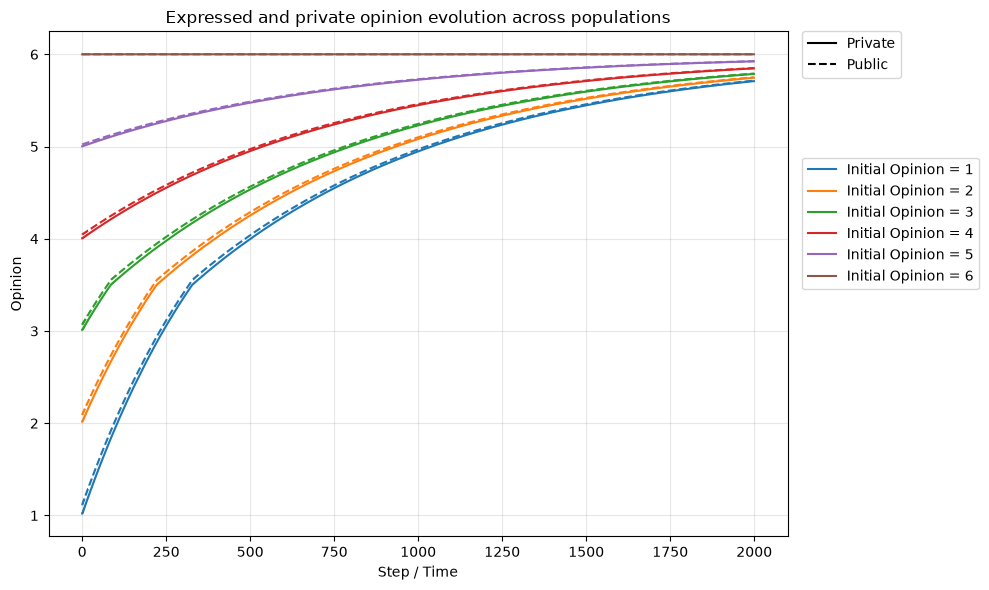

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 360,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("socio-economic", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

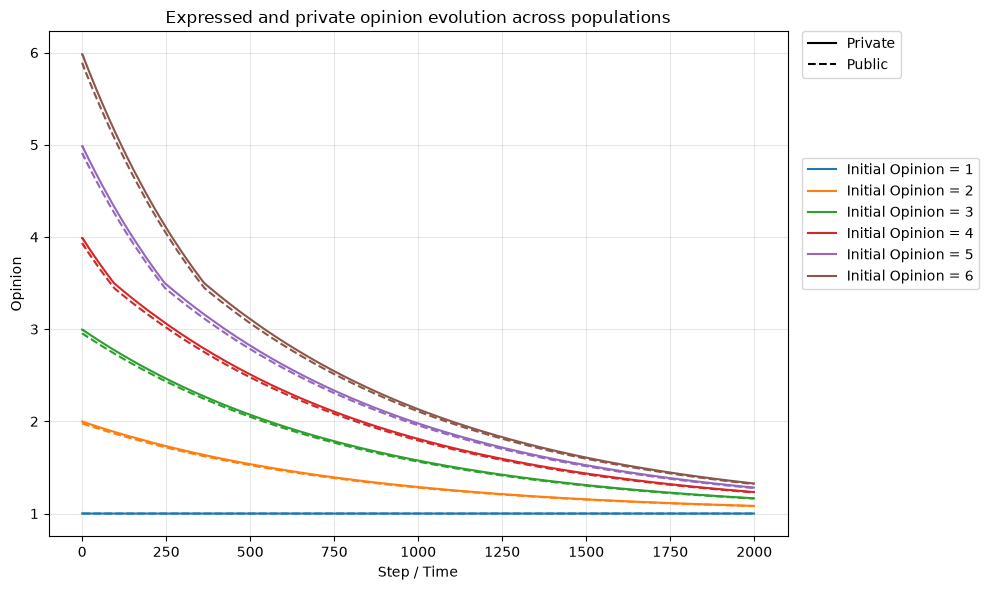

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 360,
                "opinions": { "1": 1.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 0.0 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("socio-economic", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

#### 1 Human vs 360 virtual agents

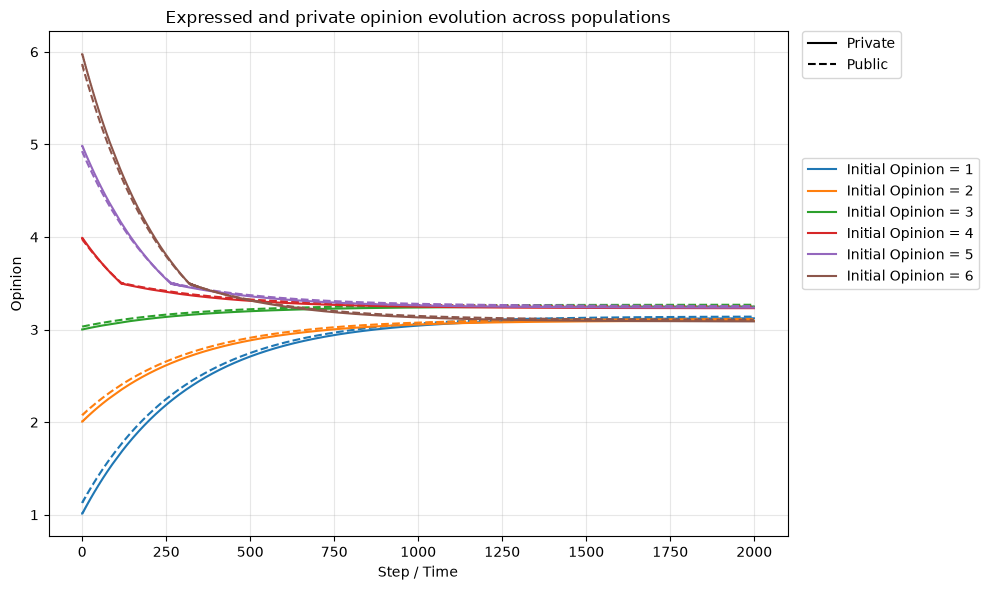

In [9]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1 }
            },
            "virtual": {
                "number": 360,
                "opinions": { "1": 0.1666, "2": 0.1667, "3": 0.1667, "4": 0.1667, "5": 0.1667, "6": 0.1666 }
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("socio-economic", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

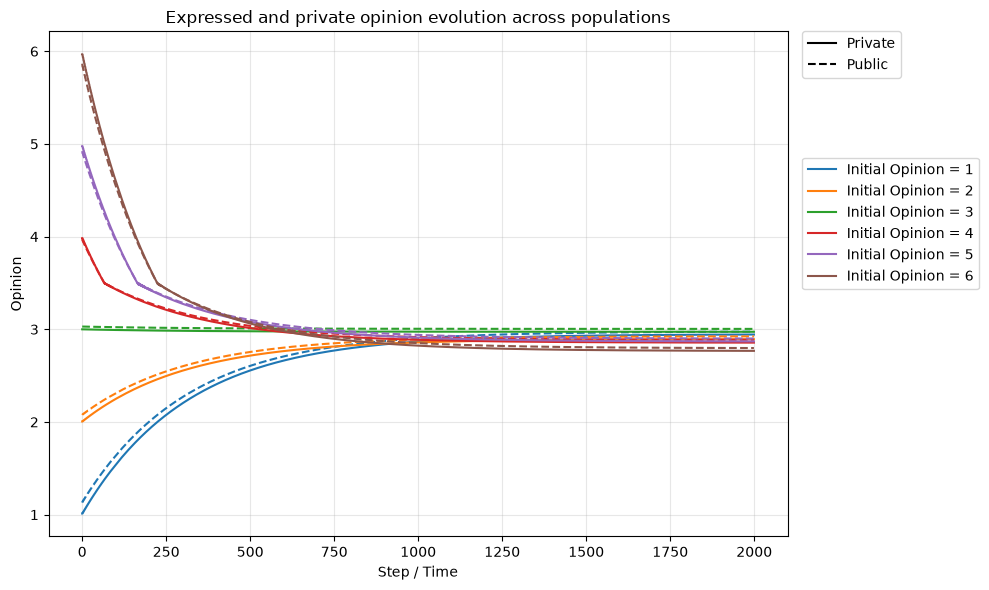

In [10]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1 }
            },
            "virtual": {
                "number": 360,
                "opinions": { "1": 0.5, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 0.5 }
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("socio-economic", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

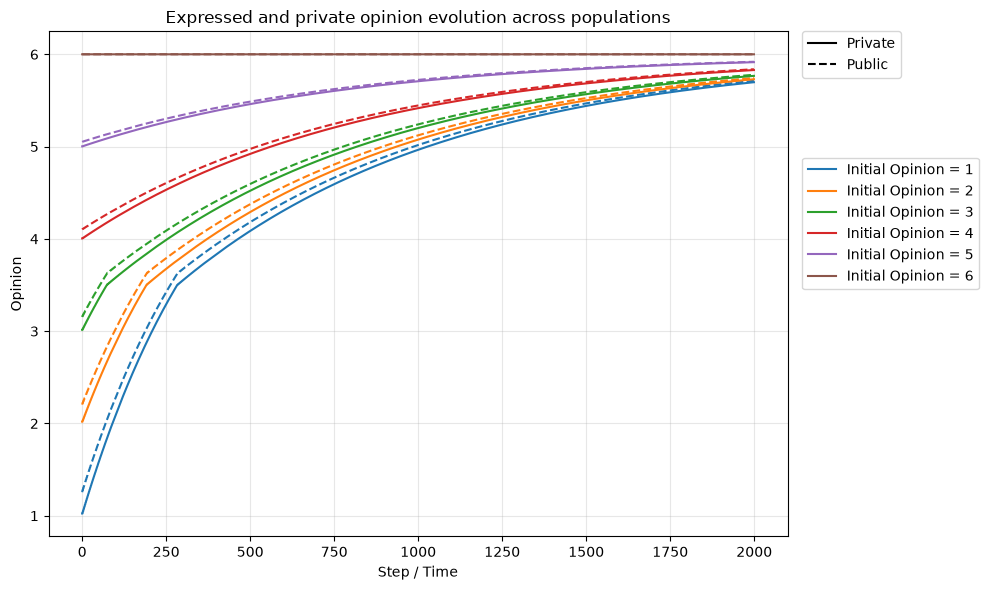

In [11]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1 }
            },
            "virtual": {
                "number": 360,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1.0 }
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("socio-economic", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

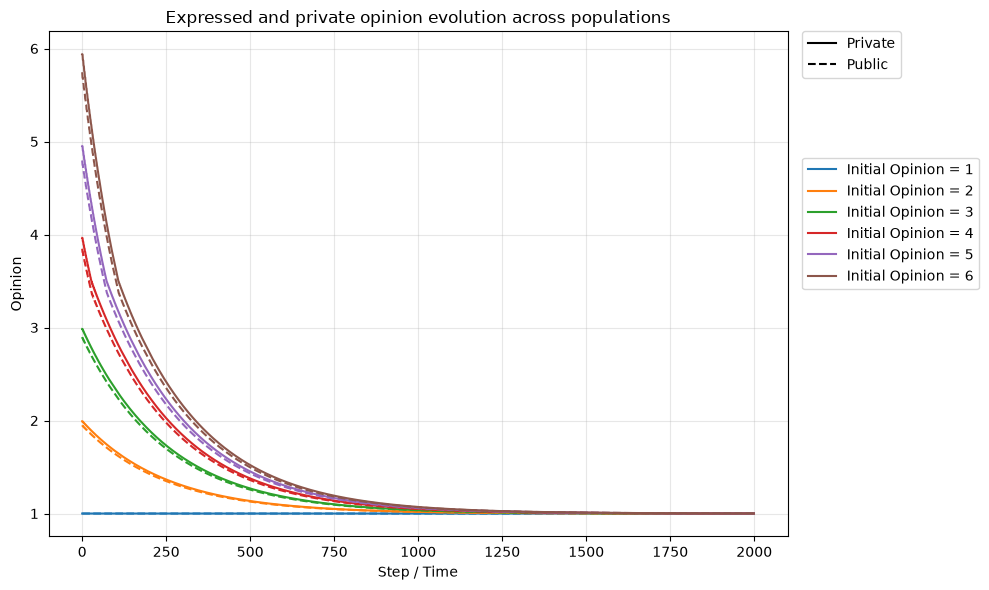

In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1 }
            },
            "virtual": {
                "number": 360,
                "opinions": { "1": 1.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 0.0 }
            },
            "article": {
                "number": 0,
                "opinions": { "1": 0, "2": 0, "3": 0.5, "4": 0.5, "5": 0, "6": 0 }
            }
        }
    }
    populations.append(Population("socio-economic", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

#### 1 Human vs 360 articles

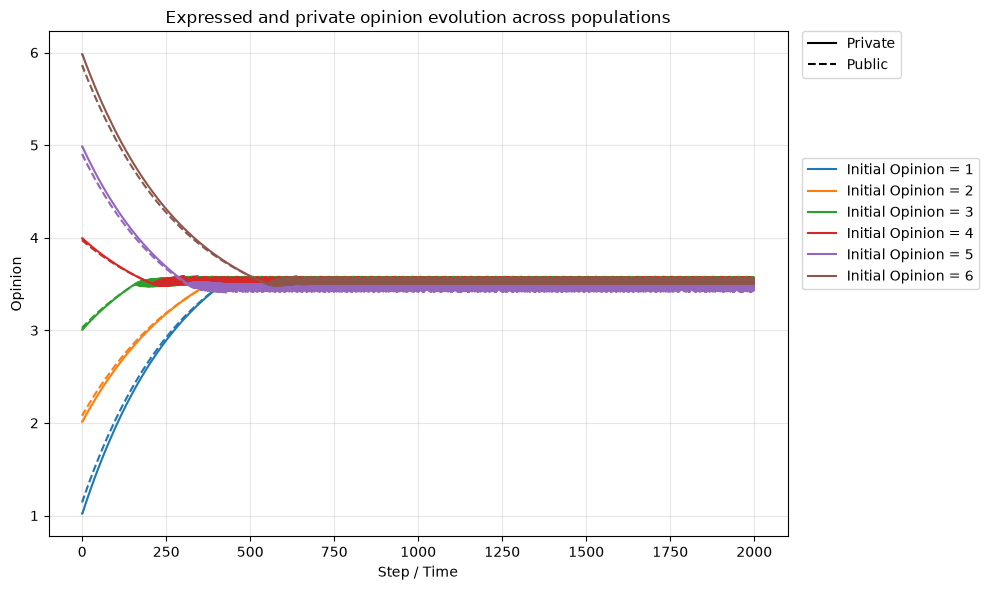

In [13]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1.0 }
            },
            "article": {
                "number": 360,
                "opinions": { "1": 0.1666, "2": 0.1667, "3": 0.1667, "4": 0.1667, "5": 0.1667, "6": 0.1666 }
            }
        }
    }
    populations.append(Population("socio-economic", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

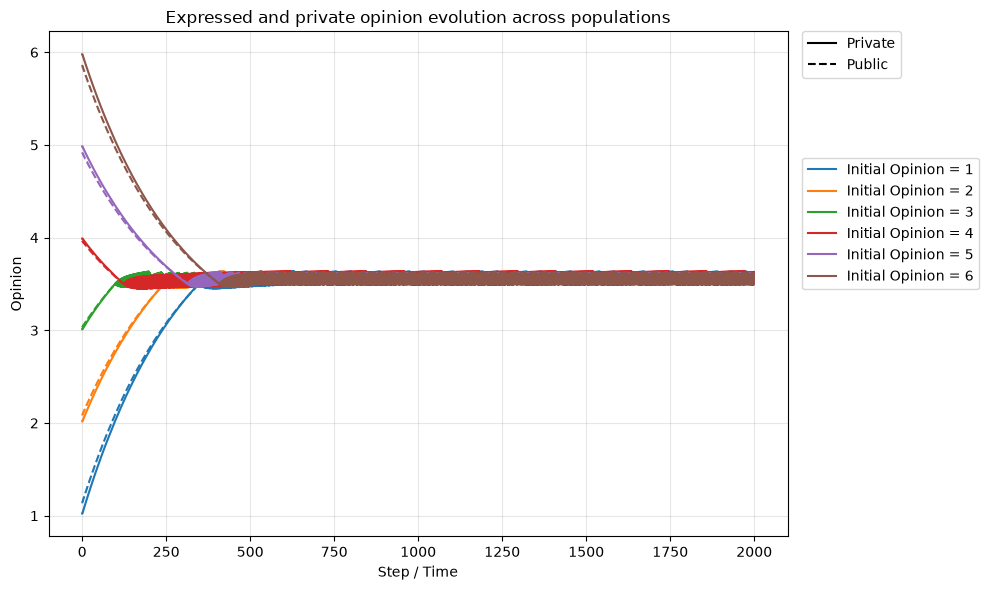

In [14]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1.0 }
            },
            "article": {
                "number": 360,
                "opinions": { "1": 0.5, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 0.5 }
            }
        }
    }
    populations.append(Population("socio-economic", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

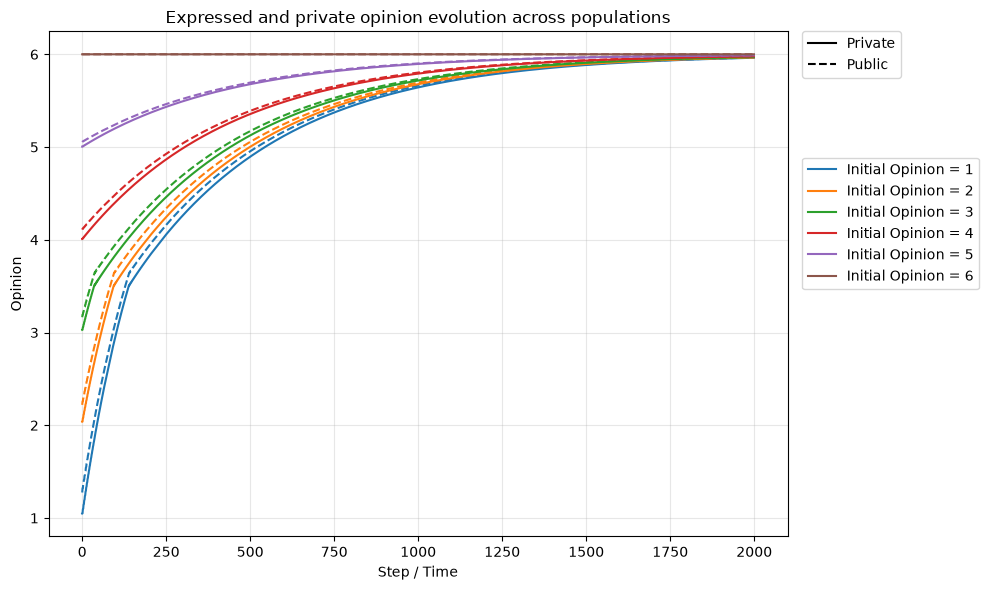

In [15]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1.0 }
            },
            "article": {
                "number": 360,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1.0 }
            }
        }
    }
    populations.append(Population("socio-economic", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

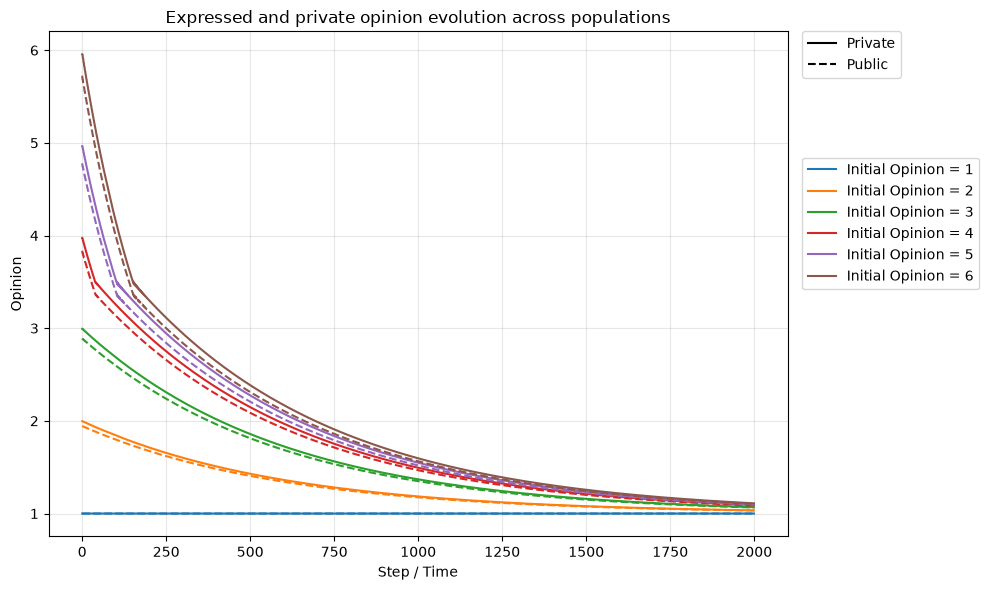

In [16]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

populations = []
opinions = [{ "1": 1, "2": 0, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 1, "3": 0, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 1, "4": 0, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 1, "5": 0, "6": 0 },
            { "1": 0, "2": 0, "3": 0, "4": 0, "5": 1, "6": 0 },
           { "1": 0, "2": 0, "3": 0, "4": 0, "5": 0, "6": 1 }]

for op in opinions:
    data = {
        "humans": {
            "number": 1,
            "opinions": op,
            "knowledge": { "low": 1, "high": 0 }
        },
        "influencers": {
            "robot": {
                "number": 0,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1 }
            },
            "virtual": {
                "number": 0,
                "opinions": { "1": 0.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 1.0 }
            },
            "article": {
                "number": 360,
                "opinions": { "1": 1.0, "2": 0.0, "3": 0.0, "4": 0.0, "5": 0.0, "6": 0.0 }
            }
        }
    }
    populations.append(Population("socio-economic", data, weights, susc, conf))

priv_opinion = []
pub_opinion = []

for p in populations:
    aux_priv = []
    aux_pub = []
    for _ in range(2000):
        p.step()
        aux_priv.append(p.get_priv_opinions()[0])
        aux_pub.append(p.get_public_opinions()[0])
    priv_opinion.append(aux_priv)
    pub_opinion.append(aux_pub)

# --- plot ---
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(populations))]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (priv_op, pub_op, color) in enumerate(zip(priv_opinion, pub_opinion, colors)):
    ax.plot(priv_op, color=color, linestyle="-", linewidth=1.5)
    ax.plot(pub_op, color=color, linestyle="--", linewidth=1.5)

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Expressed and private opinion evolution across populations")
ax.grid(True, alpha=0.3)

# legenda: estilo de linha
style_legend = [
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="Private"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Public"),
]
# legenda: cor por população
color_legend = [
    Line2D([0], [0], color=colors[i], linestyle="-", linewidth=1.5, label=f"Initial Opinion = {i+1}")
    for i in range(len(populations))
]

first_legend = ax.legend(handles=style_legend, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc="upper left", bbox_to_anchor=(1.02, 0.75), borderaxespad=0)

plt.tight_layout()
plt.show()

### RQ1: What ratio of neutral/centralist news to extreme LLMs/robots delays public polarization the most?

#### Robot_related - all robots and LLMs are pro robots

In [7]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import itertools



def run_single(n_v, n_r, i, weights, susc, conf):
    n_a = 100
    data = {
        "humans": {
            "number": 100,
            "opinions": {"1": 0.0228, "2": 0.1359, "3": 0.3413,
                         "4": 0.3413, "5": 0.1359, "6": 0.0228},
            "knowledge": {"low": 0.7, "high": 0.3}
        },
        "influencers": {
            "robot":   {"number": n_r, "opinions": {"1":0,"2":0,"3":0,"4":0,"5":0,"6":1}},
            "virtual": {"number": n_v, "opinions": {"1":0,"2":0,"3":0,"4":0,"5":0,"6":1}},
            "article": {"number": n_a, "opinions": {"1":0.0228,"2":0.1359,"3":0.3413,
                                                     "4":0.3413,"5":0.1359,"6":0.0228}}
        }
    }
    pop = Population("robot_related", data, weights, susc, conf)
    priv_opinions, pub_opinions = [], []
    for _ in range(2000):
        pop.step()
        priv_opinions.append(pop.get_priv_opinions())
        pub_opinions.append(pop.get_public_opinions())
    return (n_v, n_r, i, priv_opinions, pub_opinions)

n_values = [0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]
combos = list(itertools.product(n_values, n_values, range(1)))

results = Parallel(n_jobs=-1)(
    delayed(run_single)(n_v, n_r, i, weights, susc, conf)
    for n_v, n_r, i in tqdm(combos, desc="Simulações")
)

dic = {n_v: {n_r: {} for n_r in n_values} for n_v in n_values}
for n_v, n_r, i, priv, pub in results:
    dic[n_v][n_r][i] = {"priv_opinions": priv, "pub_opinions": pub}

Simulações:   0%|          | 0/169 [00:00<?, ?it/s]

In [8]:
import pickle
pickle.dump(dic, open('rq2_dic_robot_related_6.p', 'wb'))

In [9]:
dic=pickle.load(open('rq2_dic_robot_related_6.p', 'rb'))

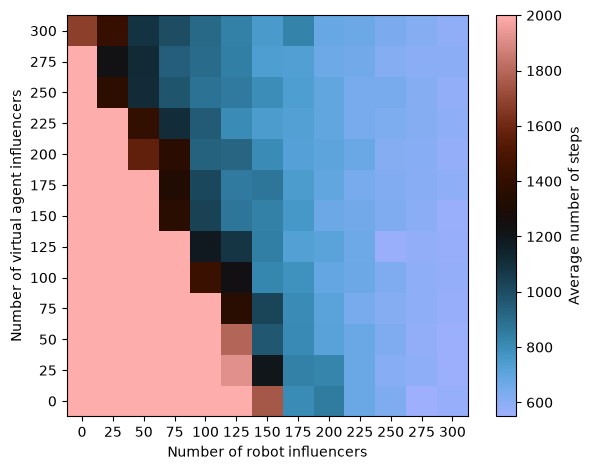

In [15]:
import matplotlib.pyplot as plt


steps = []
for p_v in [0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]:
    for p_r in [0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]:

        steps_mean = 0

        for t in range(1):
            steps_count = 0

            for i in range(2000):

                pub_opinions = dic[p_v][p_r][t]["pub_opinions"][i]

                heat = 0

                for opinion in pub_opinions:
                    if(np.round(opinion) == 1 or np.round(opinion) == 6):
                        heat += 1

                if(heat/len(pub_opinions) > 0.5):

                    steps_mean += steps_count
                    break

                steps_count += 1

            if(steps_count == 2000):
                steps_mean += 2000
        steps.append(steps_mean/1)

steps = np.array(steps).reshape(13, 13)
labels = [0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]

fig, ax = plt.subplots()
im = ax.imshow(steps, cmap="berlin", origin="lower")

# Definir as posições e os labels dos ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Nomes dos eixos
ax.set_xlabel("Number of robot influencers")
ax.set_ylabel("Number of virtual agent influencers")


# Colorbar ao lado
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Average number of steps")

fig.tight_layout()
plt.show()

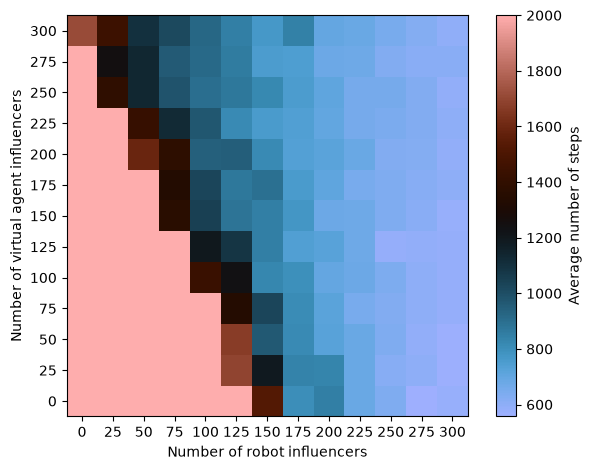

In [16]:
import matplotlib.pyplot as plt


steps = []
for p_v in [0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]:
    for p_r in [0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]:

        steps_mean = 0

        for t in range(1):
            steps_count = 0

            for i in range(2000):

                pub_opinions = dic[p_v][p_r][t]["priv_opinions"][i]

                heat = 0

                for opinion in pub_opinions:
                    if(np.round(opinion) == 1 or np.round(opinion) == 6):
                        heat += 1

                if(heat/len(pub_opinions) > 0.5):

                    steps_mean += steps_count
                    break

                steps_count += 1

            if(steps_count == 2000):
                steps_mean += 2000
        steps.append(steps_mean/1)

steps = np.array(steps).reshape(13, 13)
labels = [0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]

fig, ax = plt.subplots()
im = ax.imshow(steps, cmap="berlin", origin="lower")

# Definir as posições e os labels dos ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Nomes dos eixos
ax.set_xlabel("Number of robot influencers")
ax.set_ylabel("Number of virtual agent influencers")


# Colorbar ao lado
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Average number of steps")

fig.tight_layout()
plt.show()

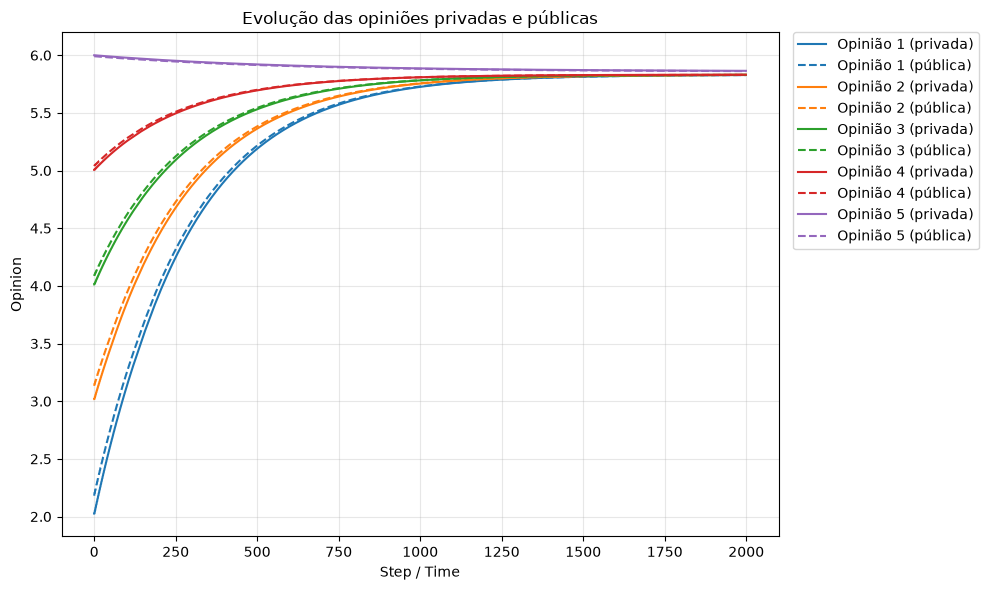

In [19]:
opinions = [1,2,3,4,5,6]
index = []

for o in opinions:
    for p in range(len(dic[300][300][0]["priv_opinions"][0])):
        op = dic[300][300][0]["priv_opinions"][0][p]
        if(np.round(op) == o):
            index.append(p)
            break

# paleta de cores, uma por opinião
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(index))]

fig, ax = plt.subplots(figsize=(10, 6))

for h, color in zip(index, colors):
    priv_opinion = [dic[300][300][0]["priv_opinions"][i][h] for i in range(2000)]
    pub_opinion = [dic[300][300][0]["pub_opinions"][i][h] for i in range(2000)]

    ax.plot(priv_opinion, color=color, linestyle="-", linewidth=1.5,
             label=f"Opinião {opinions[index.index(h)]} (privada)")
    ax.plot(pub_opinion, color=color, linestyle="--", linewidth=1.5,
             label=f"Opinião {opinions[index.index(h)]} (pública)")

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Evolução das opiniões privadas e públicas")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

#### Robot_related - all robots and LLMs are anti robots

In [129]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import itertools



def run_single(n_v, n_r, i, weights, susc, conf):
    n_a = 100
    data = {
        "humans": {
            "number": 100,
            "opinions": {"1": 0.0228, "2": 0.1359, "3": 0.3413,
                         "4": 0.3413, "5": 0.1359, "6": 0.0228},
            "knowledge": {"low": 0.7, "high": 0.3}
        },
        "influencers": {
            "robot":   {"number": n_r, "opinions": {"1":1,"2":0,"3":0,"4":0,"5":0,"6":0}},
            "virtual": {"number": n_v, "opinions": {"1":1,"2":0,"3":0,"4":0,"5":0,"6":0}},
            "article": {"number": n_a, "opinions": {"1":0.0228,"2":0.1359,"3":0.3413,
                                                     "4":0.3413,"5":0.1359,"6":0.0228}}
        }
    }
    pop = Population("robot_related", data, weights, susc, conf)
    priv_opinions, pub_opinions = [], []
    for _ in range(2000):
        pop.step()
        priv_opinions.append(pop.get_priv_opinions())
        pub_opinions.append(pop.get_public_opinions())
    return (n_v, n_r, i, priv_opinions, pub_opinions)

n_values = [0, 300, 600, 900, 1200, 1500]
combos = list(itertools.product(n_values, n_values, range(1)))

results = Parallel(n_jobs=-1)(
    delayed(run_single)(n_v, n_r, i, weights, susc, conf)
    for n_v, n_r, i in tqdm(combos, desc="Simulações")
)

dic = {n_v: {n_r: {} for n_r in n_values} for n_v in n_values}
for n_v, n_r, i, priv, pub in results:
    dic[n_v][n_r][i] = {"priv_opinions": priv, "pub_opinions": pub}

Simulações:   0%|          | 0/36 [00:00<?, ?it/s]

In [130]:
import pickle
pickle.dump(dic, open('rq2_dic_robot_related_1.p', 'wb'))

In [131]:
dic=pickle.load(open('rq2_dic_robot_related_1.p', 'rb'))

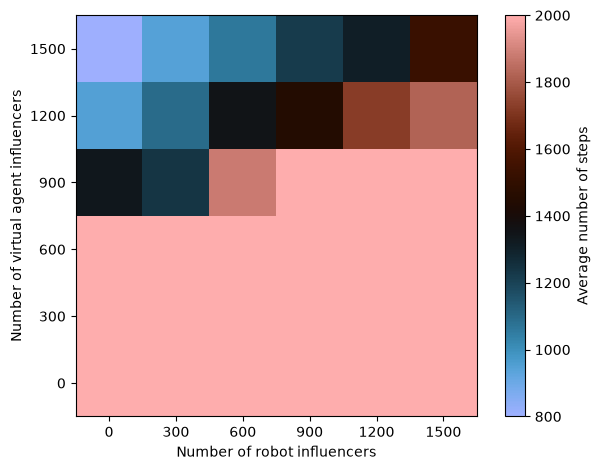

In [133]:
import matplotlib.pyplot as plt


steps = []
for p_v in [0, 300, 600, 900, 1200, 1500]:
    for p_r in [0, 300, 600, 900, 1200, 1500]:

        steps_mean = 0

        for t in range(1):
            steps_count = 0

            for i in range(2000):

                pub_opinions = dic[p_v][p_r][t]["pub_opinions"][i]

                heat = 0

                for opinion in pub_opinions:
                    if(np.round(opinion) == 1 or np.round(opinion) == 6):
                        heat += 1

                if(heat/len(pub_opinions) > 0.5):

                    steps_mean += steps_count
                    break

                steps_count += 1

            if(steps_count == 2000):
                steps_mean += 2000
        steps.append(steps_mean/1)

steps = np.array(steps).reshape(6,6)
labels = [0, 300, 600, 900, 1200, 1500]

fig, ax = plt.subplots()
im = ax.imshow(steps, cmap="berlin", origin="lower")

# Definir as posições e os labels dos ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Nomes dos eixos
ax.set_xlabel("Number of robot influencers")
ax.set_ylabel("Number of virtual agent influencers")


# Colorbar ao lado
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Average number of steps")

fig.tight_layout()
plt.show()

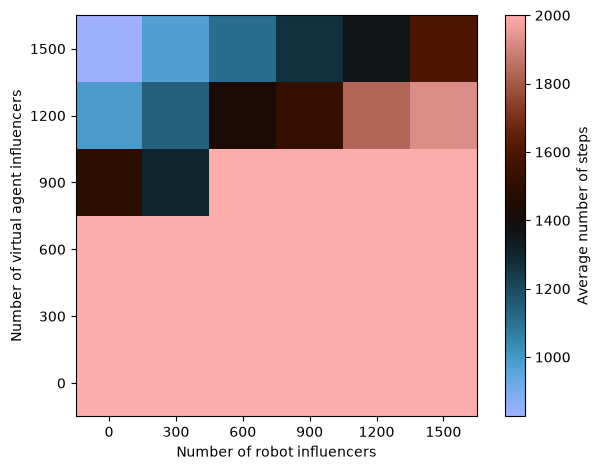

In [134]:
import matplotlib.pyplot as plt


steps = []
for p_v in [0, 300, 600, 900, 1200, 1500]:
    for p_r in [0, 300, 600, 900, 1200, 1500]:

        steps_mean = 0

        for t in range(1):
            steps_count = 0

            for i in range(2000):

                pub_opinions = dic[p_v][p_r][t]["priv_opinions"][i]

                heat = 0

                for opinion in pub_opinions:
                    if(np.round(opinion) == 1 or np.round(opinion) == 6):
                        heat += 1

                if(heat/len(pub_opinions) > 0.5):

                    steps_mean += steps_count
                    break

                steps_count += 1

            if(steps_count == 2000):
                steps_mean += 2000
        steps.append(steps_mean/1)

steps = np.array(steps).reshape(6,6)
labels = [0, 300, 600, 900, 1200, 1500]

fig, ax = plt.subplots()
im = ax.imshow(steps, cmap="berlin", origin="lower")

# Definir as posições e os labels dos ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Nomes dos eixos
ax.set_xlabel("Number of robot influencers")
ax.set_ylabel("Number of virtual agent influencers")


# Colorbar ao lado
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Average number of steps")

fig.tight_layout()
plt.show()

The same conclusion can be derived  from this figure, although in this case we are analyzing private opinion; that is, in general, it takes more steps for people to become predominantly anti-robot, but the results are identical to those of the analysis of expressed opinio

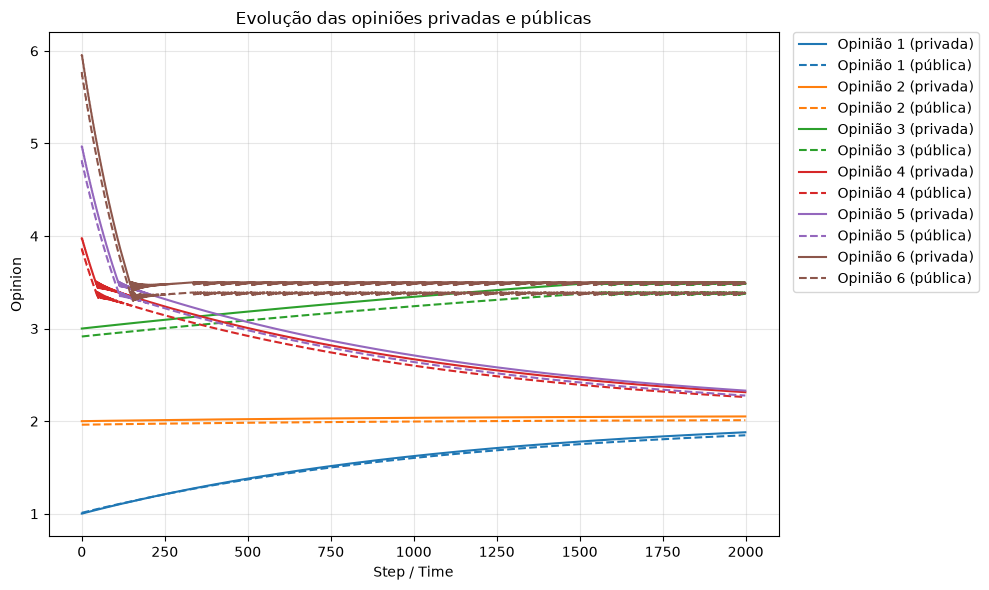

In [43]:
opinions = [1,2,3,4,5,6]
index = []

for o in opinions:
    for p in range(len(dic[300][300][0]["priv_opinions"][0])):
        op = dic[300][300][0]["priv_opinions"][0][p]
        if(np.round(op) == o):
            index.append(p)
            break

# paleta de cores, uma por opinião
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(index))]

fig, ax = plt.subplots(figsize=(10, 6))

for h, color in zip(index, colors):
    priv_opinion = [dic[300][300][0]["priv_opinions"][i][h] for i in range(2000)]
    pub_opinion = [dic[300][300][0]["pub_opinions"][i][h] for i in range(2000)]

    ax.plot(priv_opinion, color=color, linestyle="-", linewidth=1.5,
             label=f"Opinião {opinions[index.index(h)]} (privada)")
    ax.plot(pub_opinion, color=color, linestyle="--", linewidth=1.5,
             label=f"Opinião {opinions[index.index(h)]} (pública)")

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Evolução das opiniões privadas e públicas")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

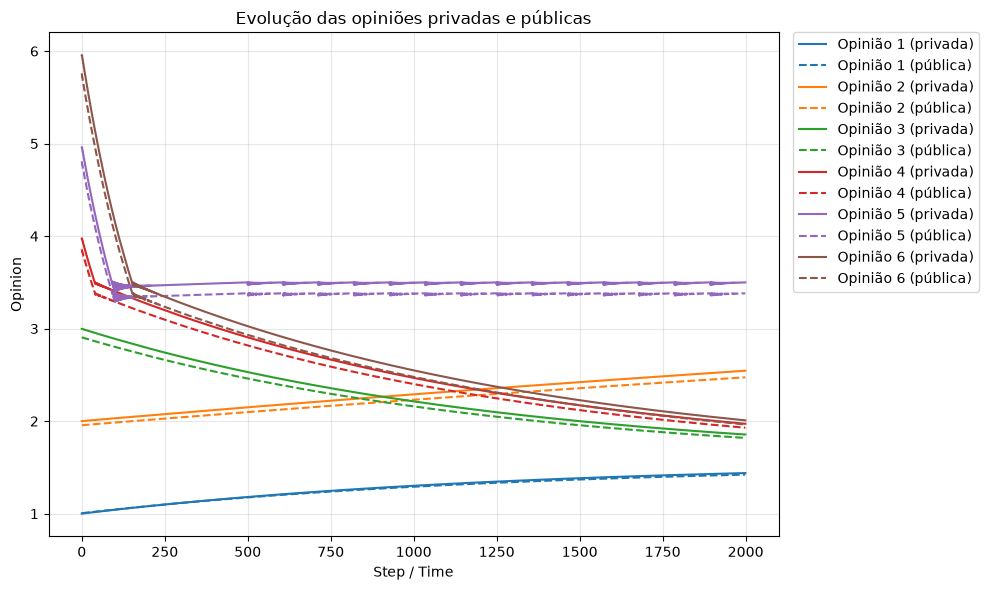

In [42]:
opinions = [1,2,3,4,5,6]
index = []

for o in opinions:
    for p in range(len(dic[600][600][0]["priv_opinions"][0])):
        op = dic[600][600][0]["priv_opinions"][0][p]
        if(np.round(op) == o):
            index.append(p)
            break

# paleta de cores, uma por opinião
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(index))]

fig, ax = plt.subplots(figsize=(10, 6))

for h, color in zip(index, colors):
    priv_opinion = [dic[600][600][0]["priv_opinions"][i][h] for i in range(2000)]
    pub_opinion = [dic[600][600][0]["pub_opinions"][i][h] for i in range(2000)]

    ax.plot(priv_opinion, color=color, linestyle="-", linewidth=1.5,
             label=f"Opinião {opinions[index.index(h)]} (privada)")
    ax.plot(pub_opinion, color=color, linestyle="--", linewidth=1.5,
             label=f"Opinião {opinions[index.index(h)]} (pública)")

ax.set_xlabel("Step / Time")
ax.set_ylabel("Opinion")
ax.set_title("Evolução das opiniões privadas e públicas")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

Above, we see the average evolution of opinions based on the initial opinion. In the first case, we observe that there was a convergence toward a value close to 1, which we can consider an extreme anti-robot opinion. In the second case, we observe that the ratio was not sufficient for the opinions to converge to 1, as we had already seen previously.

In [116]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import itertools



def run_single(n_v, n_r, i, weights, susc, conf):
    n_a = 100
    data = {
        "humans": {
            "number": 100,
            "opinions": {"1": 0.0228, "2": 0.1359, "3": 0.3413,
                         "4": 0.3413, "5": 0.1359, "6": 0.0228},
            "knowledge": {"low": 0.7, "high": 0.3}
        },
        "influencers": {
            "robot":   {"number": n_r, "opinions": {"1":0,"2":0,"3":0,"4":0,"5":0,"6":1}},
            "virtual": {"number": n_v, "opinions": {"1":0,"2":0,"3":0,"4":0,"5":0,"6":1}},
            "article": {"number": n_a, "opinions": {"1":0.0228,"2":0.1359,"3":0.3413,
                                                     "4":0.3413,"5":0.1359,"6":0.0228}}
        }
    }
    pop = Population("socio-economic", data, weights, susc, conf)
    priv_opinions, pub_opinions = [], []
    for _ in range(2000):
        pop.step()
        priv_opinions.append(pop.get_priv_opinions())
        pub_opinions.append(pop.get_public_opinions())
    return (n_v, n_r, i, priv_opinions, pub_opinions)

n_values = [0, 300, 600, 900, 1200, 1500]
combos = list(itertools.product(n_values, n_values, range(1)))

results = Parallel(n_jobs=-1)(
    delayed(run_single)(n_v, n_r, i, weights, susc, conf)
    for n_v, n_r, i in tqdm(combos, desc="Simulações")
)

dic = {n_v: {n_r: {} for n_r in n_values} for n_v in n_values}
for n_v, n_r, i, priv, pub in results:
    dic[n_v][n_r][i] = {"priv_opinions": priv, "pub_opinions": pub}

Simulações:   0%|          | 0/36 [00:00<?, ?it/s]

In [117]:
import pickle
pickle.dump(dic, open('rq2_dic_socio_economic_6.p', 'wb'))

In [118]:
dic=pickle.load(open('rq2_dic_socio_economic_6.p', 'rb'))

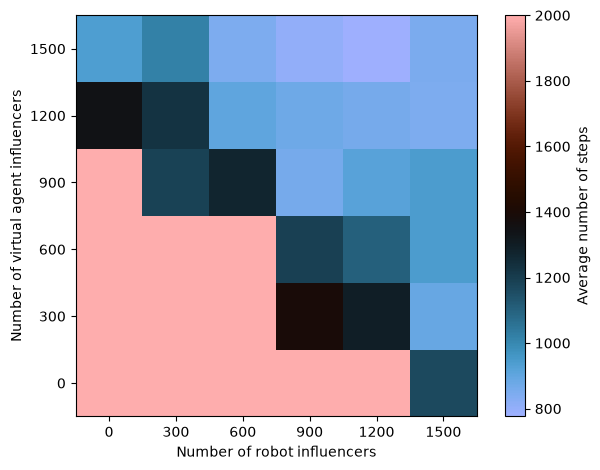

In [121]:
import matplotlib.pyplot as plt


steps = []
for p_v in [0, 300, 600, 900, 1200, 1500]:
    for p_r in [0, 300, 600, 900, 1200, 1500]:

        steps_mean = 0

        for t in range(1):
            steps_count = 0

            for i in range(2000):

                pub_opinions = dic[p_v][p_r][t]["pub_opinions"][i]

                heat = 0

                for opinion in pub_opinions:
                    if(np.round(opinion) == 1 or np.round(opinion) == 6):
                        heat += 1

                if(heat/len(pub_opinions) > 0.5):

                    steps_mean += steps_count
                    break

                steps_count += 1

            if(steps_count == 2000):
                steps_mean += 2000
        steps.append(steps_mean/1)

steps = np.array(steps).reshape(6, 6)
labels = [0, 300, 600, 900, 1200, 1500]

fig, ax = plt.subplots()
im = ax.imshow(steps, cmap="berlin", origin="lower")

# Definir as posições e os labels dos ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Nomes dos eixos
ax.set_xlabel("Number of robot influencers")
ax.set_ylabel("Number of virtual agent influencers")


# Colorbar ao lado
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Average number of steps")

fig.tight_layout()
plt.show()

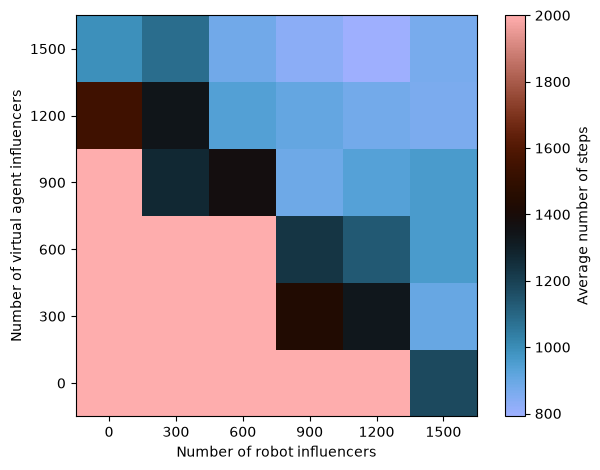

In [123]:
import matplotlib.pyplot as plt


steps = []
for p_v in [0, 300, 600, 900, 1200, 1500]:
    for p_r in [0, 300, 600, 900, 1200, 1500]:

        steps_mean = 0

        for t in range(1):
            steps_count = 0

            for i in range(2000):

                pub_opinions = dic[p_v][p_r][t]["priv_opinions"][i]

                heat = 0

                for opinion in pub_opinions:
                    if(np.round(opinion) == 1 or np.round(opinion) == 6):
                        heat += 1

                if(heat/len(pub_opinions) > 0.5):

                    steps_mean += steps_count
                    break

                steps_count += 1

            if(steps_count == 2000):
                steps_mean += 2000
        steps.append(steps_mean/1)

steps = np.array(steps).reshape(6, 6)
labels = [0, 300, 600, 900, 1200, 1500]
fig, ax = plt.subplots()
im = ax.imshow(steps, cmap="berlin", origin="lower")

# Definir as posições e os labels dos ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Nomes dos eixos
ax.set_xlabel("Number of robot influencers")
ax.set_ylabel("Number of virtual agent influencers")


# Colorbar ao lado
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Average number of steps")

fig.tight_layout()
plt.show()

In [105]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import itertools



def run_single(n_v, n_r, i, weights, susc, conf):
    n_a = 100
    data = {
        "humans": {
            "number": 100,
            "opinions": {"1": 0.0228, "2": 0.1359, "3": 0.3413,
                         "4": 0.3413, "5": 0.1359, "6": 0.0228},
            "knowledge": {"low": 0.7, "high": 0.3}
        },
        "influencers": {
            "robot":   {"number": n_r, "opinions": {"1":1,"2":0,"3":0,"4":0,"5":0,"6":0}},
            "virtual": {"number": n_v, "opinions": {"1":1,"2":0,"3":0,"4":0,"5":0,"6":0}},
            "article": {"number": n_a, "opinions": {"1":0.0228,"2":0.1359,"3":0.3413,
                                                     "4":0.3413,"5":0.1359,"6":0.0228}}
        }
    }
    pop = Population("socio-economic", data, weights, susc, conf)
    priv_opinions, pub_opinions = [], []
    for _ in range(2000):
        pop.step()
        priv_opinions.append(pop.get_priv_opinions())
        pub_opinions.append(pop.get_public_opinions())
    return (n_v, n_r, i, priv_opinions, pub_opinions)

n_values = [0, 300, 600, 900, 1200, 1500]
combos = list(itertools.product(n_values, n_values, range(1)))

results = Parallel(n_jobs=-1)(
    delayed(run_single)(n_v, n_r, i, weights, susc, conf)
    for n_v, n_r, i in tqdm(combos, desc="Simulações")
)

dic = {n_v: {n_r: {} for n_r in n_values} for n_v in n_values}
for n_v, n_r, i, priv, pub in results:
    dic[n_v][n_r][i] = {"priv_opinions": priv, "pub_opinions": pub}

Simulações:   0%|          | 0/36 [00:00<?, ?it/s]

In [106]:
import pickle
pickle.dump(dic, open('rq2_dic_socio_economic_1.p', 'wb'))

In [107]:
dic=pickle.load(open('rq2_dic_socio_economic_1.p', 'rb'))

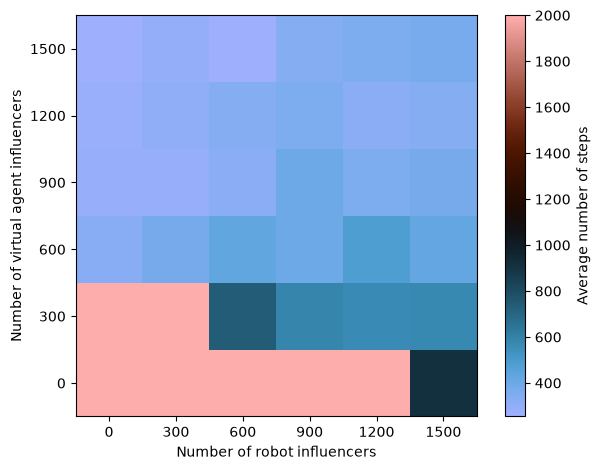

In [110]:
import matplotlib.pyplot as plt


steps = []
for p_v in [0, 300, 600, 900, 1200, 1500]:
    for p_r in [0, 300, 600, 900, 1200, 1500]:

        steps_mean = 0

        for t in range(1):
            steps_count = 0

            for i in range(2000):

                pub_opinions = dic[p_v][p_r][t]["pub_opinions"][i]

                heat = 0

                for opinion in pub_opinions:
                    if(np.round(opinion) == 1 or np.round(opinion) == 6):
                        heat += 1

                if(heat/len(pub_opinions) > 0.5):

                    steps_mean += steps_count
                    break

                steps_count += 1

            if(steps_count == 2000):
                steps_mean += 2000
        steps.append(steps_mean/1)

steps = np.array(steps).reshape(6, 6)
labels = [0, 300, 600, 900, 1200, 1500]

fig, ax = plt.subplots()
im = ax.imshow(steps, cmap="berlin", origin="lower")

# Definir as posições e os labels dos ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Nomes dos eixos
ax.set_xlabel("Number of robot influencers")
ax.set_ylabel("Number of virtual agent influencers")


# Colorbar ao lado
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Average number of steps")

fig.tight_layout()
plt.show()